# Safe-to-Play: Athlete Injury Risk Prediction

**Group:** TXC-AS  
**Course:** Machine Learning 2026  
**Dataset:** High Accuracy Sport Injury Dataset (600 athletes)

**Students:**
- 70033 Leticia Brendle
- 63889 Tom Osterwald
- 73606 Marie Christine Henke
- 71747 Romeo Heukamp
- 72561 Riccardo Bertolini
- 74626 Beatrice Volpi


**Dataset used:**
https://www.kaggle.com/datasets/yuanchunhong/sirp-600-sports-injury-risk-prediction-dataset

---

**Business Context**

Professional football clubs face a persistent tension between player availability and injury risk. Across the Premier League alone, injuries account for an estimated £400M in lost wages and performance per season, with individual clubs losing up to £45M annually.

Current decision-making relies on subjective assessment: physiotherapist observation, self-reported fatigue, and coaching intuition. This approach is inconsistent, retrospective, and blind to the multi-dimensional patterns that precede injury.

**Safe-to-Play** is a machine learning product designed for performance analytics and medical departments at professional clubs. It integrates physiological markers, training load, and recovery data into a single daily risk score per athlete, giving staff an objective and explainable signal to act on before injury occurs.

By adopting Safe-to-Play, clubs can expect to:

*[Expected outcomes and impact metrics to be added]*

This notebook documents the initial model development pipeline, built and validated on a dataset of 600 athletes. It covers the full process from raw data through to an explainable, deployable classifier, forming the technical foundation of the Safe-to-Play product.

## Table of Contents

1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
   - [1.1 Data Loading](#1.1-Data-Loading)
   - [1.2 First Look](#1.2-First-Look)
2. [Exploratory Data Analysis](#2.-Exploratory-Data-Analysis)
   - [2.1 Correlation with Target](#2.1-Correlation-with-Target)
   - [2.2 Feature Groups](#2.2-Feature-Groups)
   - [2.3 Cross-Group Interactions](#2.3-Cross-Group-Interactions)
   - [2.4 Class Separability: t-SNE Visualisation](#2.4-Class-Separability:-t-SNE-Visualisation)
   - [2.5 EDA Summary: Feature Classification](#2.5-EDA-Summary:-Feature-Classification)
3. [Feature Engineering & Preprocessing](#3.-Feature-Engineering-&-Preprocessing)
   - [3.1 Drop Excluded Features](#3.1-Drop-Excluded-Features)
   - [3.2 Feature Engineering](#3.2-Feature-Engineering)
   - [3.3 Train / Test Split](#3.3-Train-Test-Split)
   - [3.4 Scaling](#3.4-Scaling)
4. [Model Training](#4.-Model-Training)
   - [4.1 Logistic Regression with RFE](#4.1-Logistic-Regression-with-RFE)
   - [4.2 Random Forest](#4.2-Random-Forest)
   - [4.3 XGBoost](#4.3-XGBoost)
5. [Model Comparison](#5.-Model-Comparison)
6. [Model Explainability (SHAP)](#6.-Model-Explainability-(SHAP))
   - [6.1 SHAP Setup](#6.1-SHAP-Setup)
   - [6.2 Global Feature Importance](#6.2-Global-Feature-Importance)
   - [6.3 Individual Prediction Explanations](#6.3-Individual-Prediction-Explanations)
   - [6.4 Feature Group Analysis](#6.4-Feature-Group-Analysis)
7. [Business Recommendations](#7.-Business-Recommendations)
   - [7.1 Business Problem, Context and Objective](#7.1-Business-Problem,-Context-and-Objective)
   - [7.2 Actionable Recommendations](#7.2-Actionable-Recommendations)
   - [7.3 Expected Impact](#7.3-Expected-Impact)

# 1. Setup & Data Loading

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import xgboost as xgb
import shap

# Global plot settings
mpl.rc('axes',  labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
sns.set_style('whitegrid')

RANDOM_STATE = 42  # fixed seed for reproducibility across all models and splits

# Feature-group colour palette (consistent throughout the notebook)
COLOR_BIO       = '#4C72B0'  # blue, biological markers
COLOR_LOAD      = '#DD8452'  # orange, training load
COLOR_RECOVERY  = '#55A868'  # green, recovery & lifestyle
COLOR_CONDITION = '#8172B2'  # purple, physical condition
COLOR_TARGET    = ['#2196F3', '#E53935']  # blue = no risk, red = at risk

print("Libraries loaded.")

Libraries loaded.


## 1.1 Data Loading

In [2]:
df = pd.read_excel('../data/High_Accuracy_Sport_Injury_Dataset.xlsx')
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Training_Frequency,Training_Duration,Warmup_Time,Sleep_Hours,Flexibility_Score,Muscle_Asymmetry,Recovery_Time,Injury_History,Stress_Level,Training_Intensity,Injury_Risk
0,36,0,155.4,56.3,23.34,1,94,20,7.2,63.3,3.7,63,1,8,4.4,0
1,30,0,167.6,45.3,16.12,4,114,5,7.1,64.6,5.1,64,1,7,6.7,0
2,21,1,176.7,60.8,19.48,1,95,11,5.0,68.6,6.1,69,0,6,4.3,1
3,37,0,170.2,60.7,20.97,5,73,6,8.1,69.0,4.6,65,2,3,6.4,1
4,30,0,161.5,45.0,17.25,6,93,8,7.8,45.2,8.5,42,3,8,4.2,1


## 1.2 First Look

In [3]:
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

target_dist = pd.DataFrame({
    'Count': df['Injury_Risk'].value_counts(),
    '%': df['Injury_Risk'].value_counts(normalize=True).mul(100).round(1)
})
print(f"\nTarget distribution:\n{target_dist}")

Shape: (600, 16)

Data types:
Age                     int64
Gender                  int64
Height_cm             float64
Weight_kg             float64
BMI                   float64
Training_Frequency      int64
Training_Duration       int64
Warmup_Time             int64
Sleep_Hours           float64
Flexibility_Score     float64
Muscle_Asymmetry      float64
Recovery_Time           int64
Injury_History          int64
Stress_Level            int64
Training_Intensity    float64
Injury_Risk             int64
dtype: object

Missing values:
Age                   0
Gender                0
Height_cm             0
Weight_kg             0
BMI                   0
Training_Frequency    0
Training_Duration     0
Warmup_Time           0
Sleep_Hours           0
Flexibility_Score     0
Muscle_Asymmetry      0
Recovery_Time         0
Injury_History        0
Stress_Level          0
Training_Intensity    0
Injury_Risk           0
dtype: int64

Target distribution:
             Count     %
Injury_Risk    

**First look summary:**
- All 16 features are numeric (int64 / float64), so no encoding is needed for most variables
- No missing values across all 600 records. The dataset is clean and ready to use
- The target is imbalanced: **68.5% safe (0)** vs **31.5% at risk (1)**. We will account for this during modelling with stratified splits and class weighting

# 2. Exploratory Data Analysis

The EDA is structured to directly inform feature engineering decisions. We start with a full correlation overview, then dive into each feature group, and finish with cross-group interactions and a summary of what we take into Section 3.


## 2.1 Correlation with Target

Which features have the strongest relationship with injury risk?

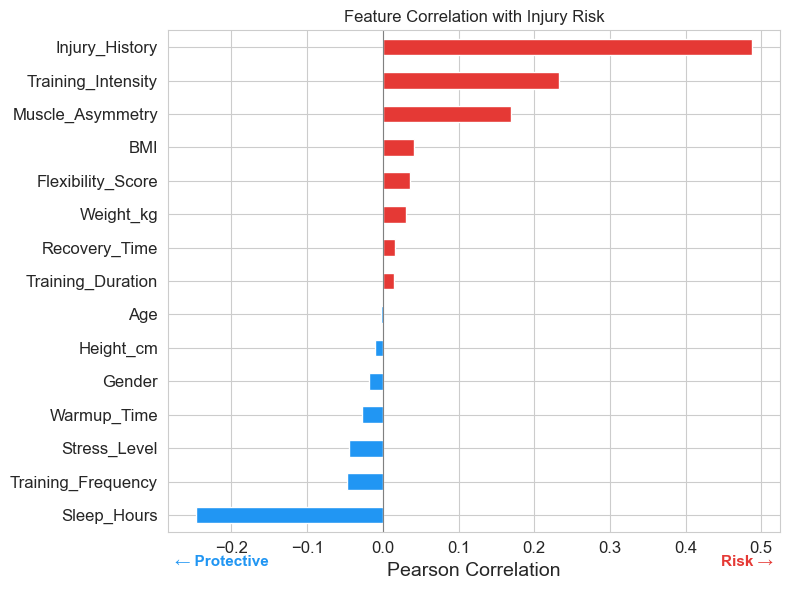

In [4]:
# Correlation of every feature with the target, sorted
corr_target = df.corr()['Injury_Risk'].drop('Injury_Risk').sort_values()

# Color bars by direction: positive = risk (red), negative = protective (blue)
bar_colors = [COLOR_TARGET[1] if c > 0 else COLOR_TARGET[0] for c in corr_target]

fig, ax = plt.subplots(figsize=(8, 6))
corr_target.plot(kind='barh', color=bar_colors, ax=ax)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_title('Feature Correlation with Injury Risk')
ax.set_xlabel('Pearson Correlation')

# Label the two sides of the axis
ax.text(ax.get_xlim()[0] + 0.01, -1.2, '← Protective', color=COLOR_TARGET[0],
        fontsize=11, fontweight='bold', va='top')
ax.text(ax.get_xlim()[1] - 0.01, -1.2, 'Risk →', color=COLOR_TARGET[1],
        fontsize=11, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

**Key takeaways:**
- `Injury_History` is by far the strongest predictor. Prior injuries are the clearest signal of future risk.
- `Sleep_Hours` is the strongest protective factor. More sleep correlates with lower injury risk.
- Training load appears interestingly strong on both sides: `Training_Intensity` is the second strongest risk factor, while `Training_Frequency` is the second strongest protective factor, followed by `Stress_Level`. Unlike history or sleep, **training load is directly controllable by coaching staff.** `Training_Duration` is notably near zero.
- `Muscle_Asymmetry` is the third strongest risk factor. It is a physical/biomechanical signal, indicating that structural imbalances independently contribute to injury.
- `Recovery_Time` and `Warmup_Time` seem to be moderate predictors.
- `Age`, `BMI`, `Height_cm` and `Weight_kg` seem to be weak predictors.

Looking at these results, four natural groups emerge. Fixed physical characteristics like height, weight and age contribute little: professional athletes tend to be homogeneous in build, so these features do not differentiate well. How an athlete trains is a much stronger signal and, uniquely, something coaching staff can directly adjust. How well an athlete recovers day-to-day — sleep, recovery time, stress — reflects behavioural and psychological readiness. Finally, physical condition assessments like muscle asymmetry, flexibility and injury history capture the current medical and biomechanical state of the body, and contain some of the strongest predictors overall.

We will use this grouping to structure the rest of the EDA, examining each group in depth:

| Group | Features |
|---|---|
| Biological markers | Age, Gender, Height_cm, Weight_kg, BMI |
| Training load | Training_Frequency, Training_Duration, Training_Intensity, Warmup_Time |
| Recovery & lifestyle | Sleep_Hours, Recovery_Time, Stress_Level |
| Physical condition | Muscle_Asymmetry, Flexibility_Score, Injury_History |

## 2.2 Feature Groups

We examine each of the four groups for distribution shape, skew and separation between safe and at-risk athletes. This tells us which features need scaling, transformation or can be dropped.

### Biological Markers

In [5]:
# Readable injury class labels for all plots in this section
df['Injury_Class'] = df['Injury_Risk'].map({0: 'Safe', 1: 'At Risk'})
palette_class = {'Safe': COLOR_TARGET[0], 'At Risk': COLOR_TARGET[1]}

/var/folders/1d/khs53zqx6vbf7rqhnxmng9rr0000gn/T/ipykernel_74310/2504417914.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Female (0)', 'Male (1)'])


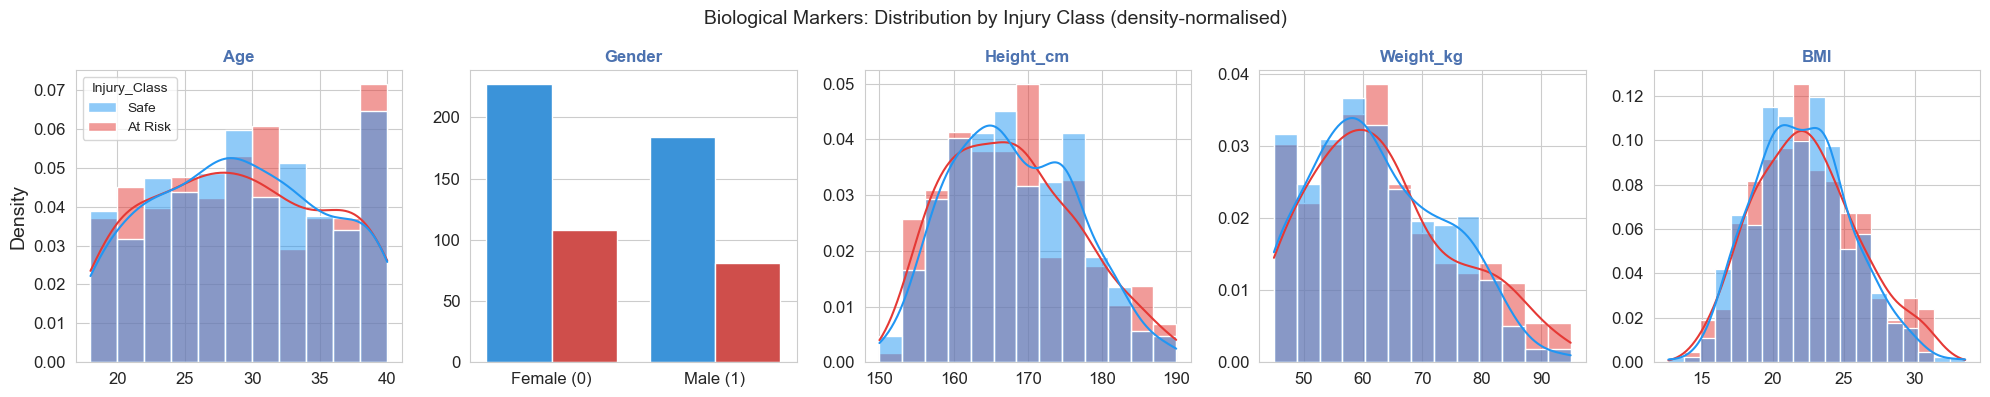

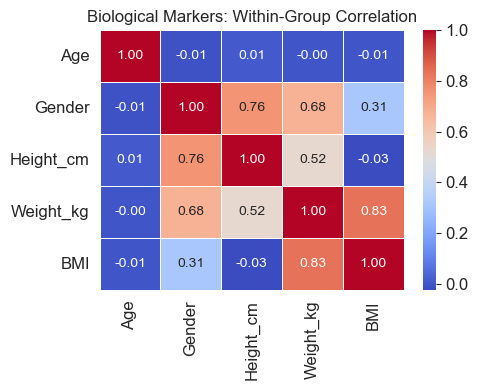

In [6]:
bio_features = ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(bio_features):
    show_legend = (i == 0)
    if df[feat].nunique() <= 2:
        sns.countplot(x=feat, hue='Injury_Class', data=df,
                      palette=palette_class, ax=axes[i],
                      order=sorted(df[feat].unique()))
        axes[i].set_xticklabels(['Female (0)', 'Male (1)'])
        if not show_legend and axes[i].get_legend():
            axes[i].get_legend().remove()
    else:
        # stat='density' normalises each class so shapes are comparable despite class imbalance
        sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                     kde=True, stat='density', common_norm=False,
                     legend=show_legend, ax=axes[i])
    axes[i].set_title(feat, color=COLOR_BIO, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Biological Markers: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[bio_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Biological Markers: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- Age, Height and Weight distributions overlap almost entirely between classes. Visually, there is little separation.
- BMI shows a slight rightward shift for at-risk athletes, but the overlap is still large.
- Gender appears relatively balanced across classes, though hard to judge from counts alone given class imbalance.
- We run two statistical tests to confirm these visual impressions before deciding what to keep.

In [7]:
from scipy.stats import chi2_contingency, mannwhitneyu

safe     = df[df['Injury_Risk'] == 0]
at_risk  = df[df['Injury_Risk'] == 1]

# Chi-squared: Gender vs Injury Risk (categorical)
contingency_table = pd.crosstab(df['Gender'], df['Injury_Risk'])
chi2, p_gender, dof, _ = chi2_contingency(contingency_table)

# Mann-Whitney U: Age vs Injury Risk (continuous, non-parametric)
stat_age, p_age = mannwhitneyu(safe['Age'], at_risk['Age'], alternative='two-sided')

print("Statistical Tests: Biological Markers")
print()
print(f"Gender (Chi-squared):  chi2={chi2:.4f},  p={p_gender:.4f}  ->  {'significant' if p_gender < 0.05 else 'not significant'}")
print(f"Age    (Mann-Whitney): U={stat_age:.0f},     p={p_age:.4f}  ->  {'significant' if p_age    < 0.05 else 'not significant'}")

Statistical Tests: Biological Markers

Gender (Chi-squared):  chi2=0.1222,  p=0.7267  ->  not significant
Age    (Mann-Whitney): U=39026,     p=0.9248  ->  not significant


**Feature classification: Biological Markers**

| Feature | p-value | Classification |
|---|---|---|
| `BMI` | n/a | Test to drop in model phase |
| `Gender` | 0.05+ | Descriptive variable (demographic control) |
| `Age` | 0.05+ | Excluded (near-zero correlation, not significant) |
| `Height_cm` | n/a | Excluded (redundant with BMI) |
| `Weight_kg` | n/a | Excluded (redundant with BMI) |

See 2.4 for the full feature classification across all groups.

### Training Load

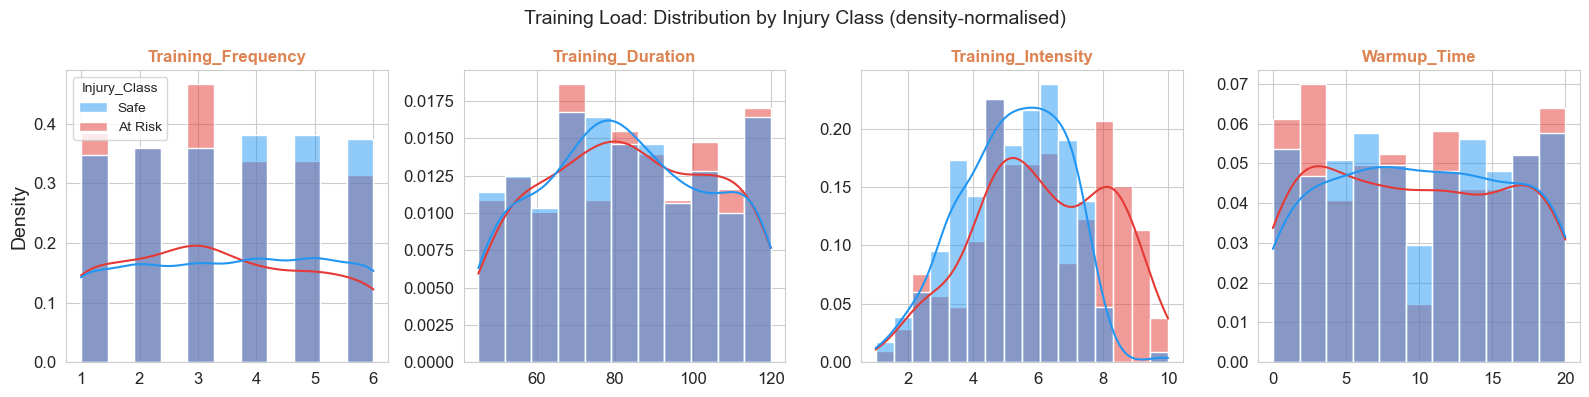

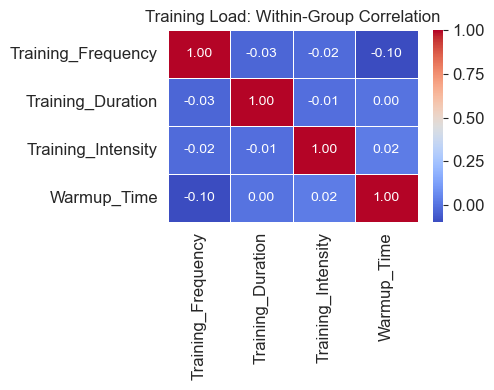

In [8]:
load_features = ['Training_Frequency', 'Training_Duration', 'Training_Intensity', 'Warmup_Time']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(load_features):
    sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                 kde=True, stat='density', common_norm=False,
                 legend=(i == 0), ax=axes[i])
    axes[i].set_title(feat, color=COLOR_LOAD, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Training Load: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[load_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Training Load: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Training_Intensity` shows the clearest separation between classes. At-risk athletes tend to train at higher intensities.
- `Training_Frequency` shifts slightly toward lower values for at-risk athletes, suggesting less frequent but harder training is a risk pattern.
- `Training_Duration` and `Warmup_Time` show heavy overlap. Their individual signal looks weak visually.
- No multicollinearity within this group (heatmap near zero). We run Mann-Whitney U tests to confirm which features are statistically significant.

In [9]:
print("Statistical Tests: Training Load (Mann-Whitney U)\n")
for feat in load_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Training Load (Mann-Whitney U)

  Training_Frequency        U=41121,  p=0.2408  ->  not significant
  Training_Duration         U=38128,  p=0.7185  ->  not significant
  Training_Intensity        U=28776,  p=0.0000  ->  significant
  Warmup_Time               U=40210,  p=0.4870  ->  not significant


**Feature classification: Training Load**

| Feature | p-value | Classification |
|---|---|---|
| `Training_Intensity` | 0.0000 | Clear good feature |
| `Training_Frequency` | 0.2408 | Test to drop in model phase |
| `Training_Duration` | 0.7185 | Test to drop in model phase |
| `Warmup_Time` | 0.4870 | Test to drop in model phase |

See 2.4 for the full feature classification across all groups.

### Recovery & Lifestyle

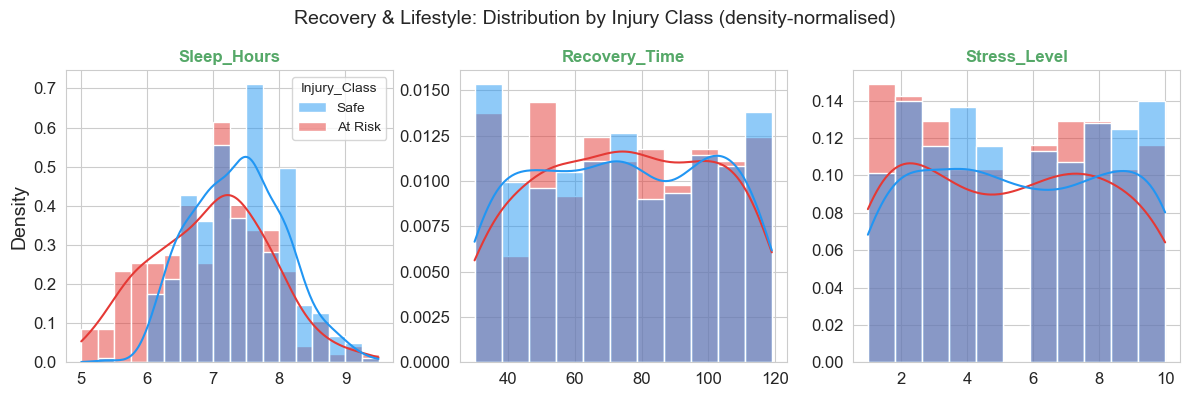

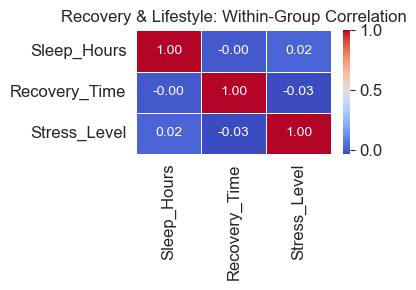

In [10]:
recovery_features = ['Sleep_Hours', 'Recovery_Time', 'Stress_Level']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, feat in enumerate(recovery_features):
    sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                 kde=True, stat='density', common_norm=False,
                 legend=(i == 0), ax=axes[i])
    axes[i].set_title(feat, color=COLOR_RECOVERY, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Recovery & Lifestyle: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df[recovery_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Recovery & Lifestyle: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Sleep_Hours` shows a clear leftward shift for at-risk athletes. Less sleep is visually the strongest signal in this group.
- `Stress_Level` shows a slight separation but in the protective direction, which is counterintuitive.
- `Recovery_Time` shows heavy overlap between classes. Its signal looks weak visually.
- We run Mann-Whitney U tests to confirm significance before deciding what to keep.

In [11]:
print("Statistical Tests: Recovery & Lifestyle (Mann-Whitney U)\n")
for feat in recovery_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Recovery & Lifestyle (Mann-Whitney U)

  Sleep_Hours               U=49461,  p=0.0000  ->  significant
  Recovery_Time             U=38060,  p=0.6929  ->  not significant
  Stress_Level              U=41032,  p=0.2640  ->  not significant


**Feature classification: Recovery & Lifestyle**

| Feature | p-value | Classification |
|---|---|---|
| `Sleep_Hours` | 0.0000 | Clear good feature |
| `Stress_Level` | 0.2640 | Test to drop in model phase |
| `Recovery_Time` | 0.6929 | Test to drop in model phase |

See 2.4 for the full feature classification across all groups.

### Physical Condition

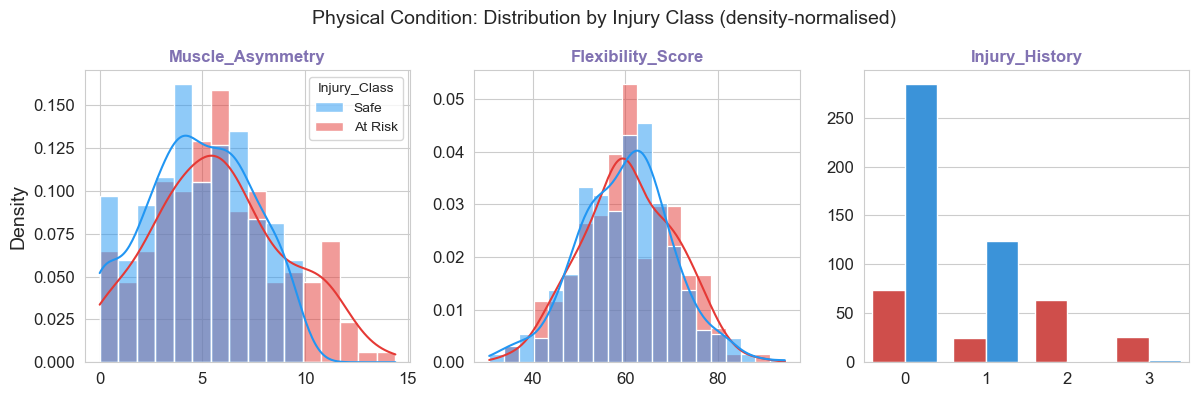

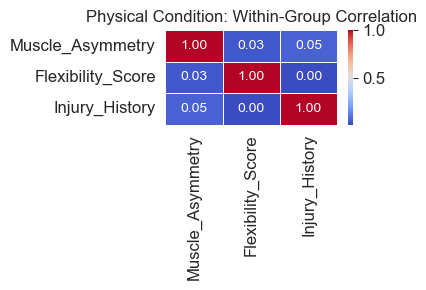

In [12]:
condition_features = ['Muscle_Asymmetry', 'Flexibility_Score', 'Injury_History']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, feat in enumerate(condition_features):
    show_legend = (i == 0)
    if df[feat].nunique() <= 5:  # treat as categorical if few unique values
        sns.countplot(x=feat, hue='Injury_Class', data=df,
                      palette=palette_class, ax=axes[i],
                      order=sorted(df[feat].unique()))
        if not show_legend and axes[i].get_legend():
            axes[i].get_legend().remove()
    else:
        sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                     kde=True, stat='density', common_norm=False,
                     legend=show_legend, ax=axes[i])
    axes[i].set_title(feat, color=COLOR_CONDITION, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Physical Condition: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df[condition_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Physical Condition: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Injury_History` shows the starkest separation of any feature in the entire dataset. Athletes with prior injuries are heavily concentrated in the at-risk class.
- `Muscle_Asymmetry` shows a rightward shift for at-risk athletes. Structural imbalances appear to be a meaningful signal.
- `Flexibility_Score` shows considerable overlap. Its value as a standalone predictor looks limited visually.
- We run Mann-Whitney U tests to confirm which features are statistically significant.

In [13]:
print("Statistical Tests: Physical Condition (Mann-Whitney U)\n")
for feat in condition_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Physical Condition (Mann-Whitney U)

  Muscle_Asymmetry          U=32240,  p=0.0008  ->  significant
  Flexibility_Score         U=37330,  p=0.4441  ->  not significant
  Injury_History            U=21717,  p=0.0000  ->  significant


**Feature classification: Physical Condition**

| Feature | p-value | Classification |
|---|---|---|
| `Injury_History` | 0.0000 | Clear good feature |
| `Muscle_Asymmetry` | 0.0008 | Clear good feature |
| `Flexibility_Score` | 0.4441 | Test to drop in model phase |

See 2.4 for the full feature classification across all groups.

## 2.3 Cross-Group Interactions

A full correlation matrix across all features. This reveals multicollinearity between groups and hints at interaction features worth engineering (e.g. high training intensity combined with low sleep).

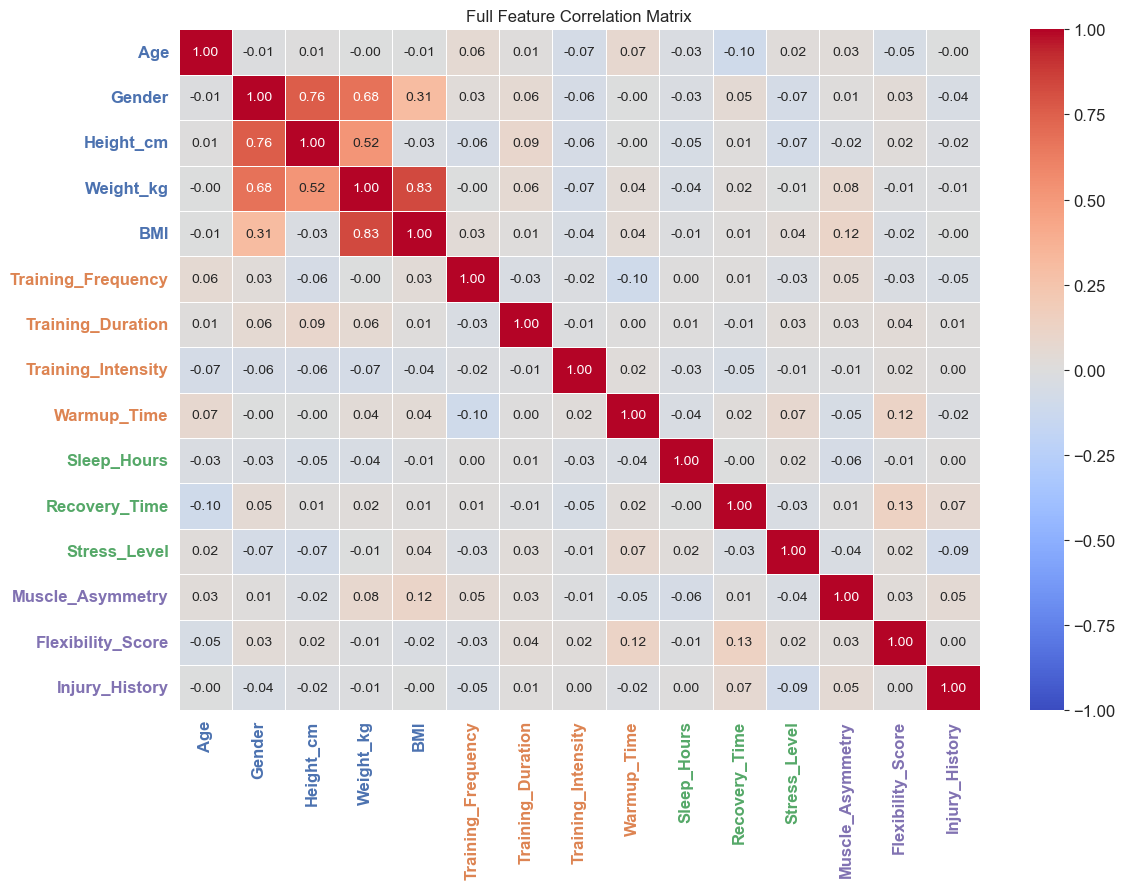

In [14]:
# Full correlation matrix, ordered by feature group for readability
all_features = bio_features + load_features + recovery_features + condition_features
corr_full = df[all_features].corr()

# Map each feature to its group color
feature_colors = (
    {f: COLOR_BIO       for f in bio_features} |
    {f: COLOR_LOAD      for f in load_features} |
    {f: COLOR_RECOVERY  for f in recovery_features} |
    {f: COLOR_CONDITION for f in condition_features}
)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Full Feature Correlation Matrix')

# Color axis labels by feature group
for tick in ax.get_xticklabels():
    tick.set_color(feature_colors.get(tick.get_text(), 'black'))
    tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
    tick.set_color(feature_colors.get(tick.get_text(), 'black'))
    tick.set_fontweight('bold')

plt.tight_layout()
plt.show()

**Cross-group observations:**

**Multicollinearity within biological markers:** `Height_cm`, `Weight_kg` and `BMI` are highly correlated (Weight-BMI: r=0.83, Gender-Height: r=0.76, Gender-Weight: r=0.68). `Gender` is essentially a size proxy in this dataset: males tend to be taller and heavier, which explains why gender itself adds no independent injury signal. We retain only `BMI` and drop the rest.

**The four strongest predictors are independent from each other:** `Injury_History`, `Training_Intensity`, `Sleep_Hours` and `Muscle_Asymmetry` show near-zero correlations with one another. This is important: they capture genuinely different aspects of athlete condition with no redundancy. For a Logistic Regression model, low multicollinearity among key features means coefficients will be stable and interpretable.

**Stress and sleep are unrelated:** `Stress_Level` and `Sleep_Hours` show near-zero correlation (-0.09). One might expect high stress to reduce sleep in professional athletes, but this dataset suggests the two are driven by different factors. It also confirms they would not be redundant if both were kept.

**Two combinations worth investigating:** `Training_Intensity` is independent from both `Training_Duration` (r≈-0.01) and `Sleep_Hours` (r≈-0.03), meaning athletes vary freely across all combinations of these dimensions. From a coaching perspective this raises two natural questions: does the total cost of a session (intensity × duration) matter beyond either factor alone, and does training hard while sleeping poorly create a risk that neither feature captures individually? We explore both as engineered features in Section 3.2.

## 2.4 Class Separability: t-SNE Visualisation

Before building any model, it is worth asking: do the features together actually separate safe from at-risk athletes? t-SNE compresses all 12 features into 2 dimensions while trying to keep similar athletes close together. The result is a scatter plot where each dot is one athlete. If the two classes form distinct clusters, a classifier will have a good chance of learning the boundary.

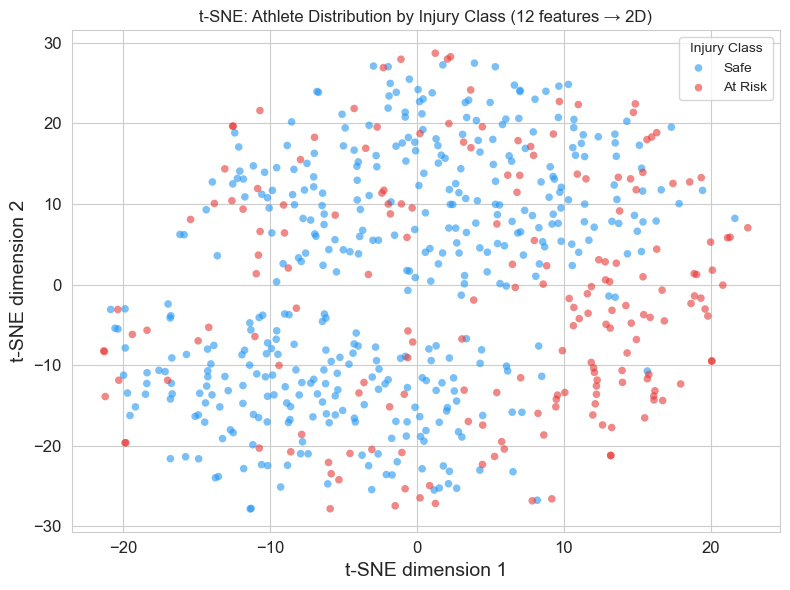

In [15]:
from sklearn.manifold import TSNE

# Use the same 12 features that enter the models (excluding Age, Height_cm, Weight_kg)
tsne_features = [c for c in df.columns if c not in
                 ['Age', 'Height_cm', 'Weight_kg', 'Injury_Risk', 'Injury_Class']]

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(StandardScaler().fit_transform(df[tsne_features]))

tsne_df = pd.DataFrame({'x': X_tsne[:, 0], 'y': X_tsne[:, 1],
                        'Injury_Class': df['Injury_Class']})

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [('Safe', COLOR_TARGET[0]), ('At Risk', COLOR_TARGET[1])]:
    mask = tsne_df['Injury_Class'] == label
    ax.scatter(tsne_df.loc[mask, 'x'], tsne_df.loc[mask, 'y'],
               c=color, label=label, alpha=0.6, s=30, edgecolors='none')

ax.set_title('t-SNE: Athlete Distribution by Injury Class (12 features → 2D)')
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
ax.legend(title='Injury Class')
plt.tight_layout()
plt.show()

*Note: t-SNE output is stochastic and may vary across scikit-learn versions. Results shown here were produced with scikit-learn 1.8.0. If your plot looks different, please ensure you are using the most recent version of scikit-learn to reproduce this output accurately.*

The t-SNE plot shows that safe (blue) and at-risk (red) athletes are broadly intermingled across the 2D space. There are no compact, well-separated clusters — red dots appear throughout the plot alongside blue ones. This tells us the 12 features do not collectively produce a clean, linearly separable boundary in the data.

That said, the distribution is not completely random. Looking at the right side and lower regions of the plot, there is a slight tendency for red dots to be more concentrated, while the central and upper-left regions are more heavily blue. This partial, soft separation suggests the features carry *some* signal, but the injury risk boundary in this dataset is fuzzy and complex.

The practical implication for modelling: accuracy ceilings will be real. No model will achieve near-perfect classification here. We can expect non-linear models (Random Forest, XGBoost) to outperform Logistic Regression by capturing subtle local patterns that the t-SNE structure hints at, but the overlap means false negatives and false positives will remain in any model's predictions.

## 2.5 EDA Summary: Feature Classification

We organised the 15 features into four groups based on what they measure: biological markers, training load, recovery & lifestyle, and physical condition. Across all groups, the EDA reveals a clear pattern. Physical condition is the strongest signal, with `Injury_History` and `Muscle_Asymmetry` standing out. Training load is uniquely two-sided: high intensity increases risk, while frequency is protective. Sleep is the strongest lifestyle factor. Biological markers contribute little, likely because athletes in a professional club are physically homogeneous.

The cross-group correlation matrix in 2.3 was largely clean, with no problematic dependencies between groups. The main finding was a set of independent relationships within the training load and recovery features that hint at potentially informative combinations. We act on this in Section 3.2.

The t-SNE visualisation in 2.4 adds an important caveat: even combining all 12 features, the two classes remain broadly intermingled. There is no clean separable boundary. This means we should expect models to struggle with borderline cases and that recall on the at-risk class, the most costly error, will be the key metric to watch in Section 4.

All 15 features are classified below, ordered from most to least predictive, based on correlation with the target (2.1) and statistical significance from the group-level tests.

| Feature | r with target | Significant? | Classification |
|---|---|---|---|
| `Injury_History` | 0.49 | Yes | **Clear good feature** |
| `Training_Intensity` | 0.23 | Yes | **Clear good feature** |
| `Sleep_Hours` | -0.25 | Yes | **Clear good feature** |
| `Muscle_Asymmetry` | 0.17 | Yes | **Clear good feature** |
| `Training_Frequency` | -0.13 | No | Test to drop in model phase |
| `Stress_Level` | -0.12 | No | Test to drop in model phase |
| `BMI` | 0.07 | No | Test to drop in model phase |
| `Flexibility_Score` | 0.07 | No | Test to drop in model phase |
| `Warmup_Time` | -0.08 | No | Test to drop in model phase |
| `Training_Duration` | 0.05 | No | Test to drop in model phase |
| `Recovery_Time` | 0.04 | No | Test to drop in model phase |
| `Gender` | -0.05 | No | Descriptive variable (kept as demographic control) |
| `Age` | 0.00 | No | Excluded |
| `Height_cm` | 0.00 | No | Excluded (redundant with BMI) |
| `Weight_kg` | 0.00 | No | Excluded (redundant with BMI) |

"Test to drop in model phase" features will be included in Section 3 and evaluated during model comparison. Features that do not contribute to performance will be removed at that stage.

**Steps in Section 3:**
- Apply `StandardScaler` to all continuous features (different scales and units)
- Split: 70% train / 30% test, stratified on target, `random_state=42`. Model selection via 5-fold `StratifiedKFold` cross-validation on the train set. Test set held out for final evaluation only.

# 3. Feature Engineering & Preprocessing

The EDA identified which features to keep and which to exclude. Before modelling we take two additional steps: create two domain-motivated composite features that capture athlete stress and workload in ways the raw features cannot, then prepare the data for training by splitting and scaling.

## 3.1 Drop Excluded Features

We remove `Age`, `Height_cm` and `Weight_kg` as established in the EDA. `Injury_Class` (the readable label column created for plots) is also removed as it is not a model input.

In [16]:
cols_to_drop = ['Age', 'Height_cm', 'Weight_kg', 'Injury_Class']
df_model = df.drop(columns=cols_to_drop)

X = df_model.drop(columns=['Injury_Risk'])
y = df_model['Injury_Risk']

print(f"Features going into modelling ({X.shape[1]}): {list(X.columns)}")
print(f"Target: Injury_Risk, shape: {y.shape}")

Features going into modelling (12): ['Gender', 'BMI', 'Training_Frequency', 'Training_Duration', 'Warmup_Time', 'Sleep_Hours', 'Flexibility_Score', 'Muscle_Asymmetry', 'Recovery_Time', 'Injury_History', 'Stress_Level', 'Training_Intensity']
Target: Injury_Risk, shape: (600,)


## 3.2 Feature Engineering

Section 2.3 flagged a cross-group pattern worth investigating: `Training_Intensity` and `Sleep_Hours` are independently strong predictors, pointing in opposite directions, and coaching intuition suggests their *combination* matters more than either alone. An athlete pushing hard while sleeping poorly is in a qualitatively different situation from one doing the same training load with adequate rest.

To test this, we check whether a ratio of the two features carries more signal than the individual features:

- `Training_Intensity` vs target: r=+0.23 (risk factor)
- `Sleep_Hours` vs target: r=-0.25 (protective factor)
- Correlation between them: r≈-0.03 (essentially independent)

The near-zero mutual correlation is what makes the ratio statistically valid: because the two features vary independently across athletes, the ratio `Training_Intensity / Sleep_Hours` spans a genuinely wide range of combinations, from athletes who train lightly and sleep well to those who train hard and sleep poorly. If the features were correlated, the ratio would be redundant with either parent. Because they are not, the ratio creates a new dimension of information.

The same logic applies to `Training_Intensity × Training_Duration`. Intensity and duration are also uncorrelated (r≈-0.01), so their product captures the total physiological cost of a session, a concept known as session-RPE in sports science, rather than simply restating either dimension alone.

We create both features below and validate with a correlation check before proceeding to modelling.

In [17]:
df_model = df_model.copy()

# Load-Recovery Ratio: how hard an athlete trains relative to how well they recover
df_model['Load_Recovery_Ratio'] = df_model['Training_Intensity'] / df_model['Sleep_Hours']

# Total Training Load: combined physiological cost of a session (intensity × duration)
df_model['Training_Load'] = df_model['Training_Intensity'] * df_model['Training_Duration']

X = df_model.drop(columns=['Injury_Risk'])
y = df_model['Injury_Risk']

print(f"Features after engineering ({X.shape[1]}): {list(X.columns)}")

# Quick sanity check: correlation of new features with target
new_feats = ['Load_Recovery_Ratio', 'Training_Load']
corr_new = df_model[new_feats + ['Injury_Risk']].corr()['Injury_Risk'].drop('Injury_Risk')
print(f"\nCorrelation with Injury_Risk:")
print(corr_new.round(4))

Features after engineering (14): ['Gender', 'BMI', 'Training_Frequency', 'Training_Duration', 'Warmup_Time', 'Sleep_Hours', 'Flexibility_Score', 'Muscle_Asymmetry', 'Recovery_Time', 'Injury_History', 'Stress_Level', 'Training_Intensity', 'Load_Recovery_Ratio', 'Training_Load']

Correlation with Injury_Risk:
Load_Recovery_Ratio    0.3033
Training_Load          0.1755
Name: Injury_Risk, dtype: float64


The correlations confirm the engineering decisions were well-founded. `Load_Recovery_Ratio` (r=0.30) becomes the third strongest predictor in the entire feature set, ranking above both `Training_Intensity` (r=0.23) and `Muscle_Asymmetry` (r=0.17). This validates the hypothesis from Section 2.3: combining two uncorrelated but individually predictive features into a ratio captures signal that neither parent feature contains alone. `Training_Load` (r=0.18) also adds meaningful signal beyond what `Training_Intensity` or `Training_Duration` provide individually.

Both engineered features will be included in the RFE ranking for Logistic Regression and passed alongside all 14 features to Random Forest and XGBoost.

## 3.3 Train / Test Split

We split into 70% train and 30% test. The train set is used with 5-fold cross-validation for model selection. The test set is held out completely and only used for final evaluation.

In [18]:
from sklearn.model_selection import StratifiedKFold

# 70% train, 30% test, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# StratifiedKFold for cross-validation on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("Class balance per split:")
for name, y_split in [("Train", y_train), ("Test", y_test)]:
    pct = y_split.value_counts(normalize=True).mul(100).round(1)
    print(f"  {name:<8}: Safe {pct[0]}%  |  At Risk {pct[1]}%")
print()
print(f"Cross-validation: {cv.n_splits}-fold StratifiedKFold on train set")

Train : 420 samples (70%)
Test  : 180 samples (30%)

Class balance per split:
  Train   : Safe 68.6%  |  At Risk 31.4%
  Test    : Safe 68.3%  |  At Risk 31.7%

Cross-validation: 5-fold StratifiedKFold on train set


## 3.4 Scaling

`StandardScaler` is fitted on the training set only and applied to the test set. This prevents data leakage: the test set must not influence the scaling parameters. The two engineered features are scaled alongside the originals.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same scale to test

# Wrap back into DataFrames to keep feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Scaling complete.")
print(f"Train mean (should be ~0): {X_train_scaled.mean().round(2).values}")
print(f"Train std  (should be ~1): {X_train_scaled.std().round(2).values}")

Scaling complete.
Train mean (should be ~0): [-0. -0.  0. -0. -0.  0.  0. -0.  0. -0. -0. -0.  0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Section 3 summary:**
- 3 features excluded: `Age`, `Height_cm`, `Weight_kg`
- 2 composite features created: `Load_Recovery_Ratio`, `Training_Load`
- 14 features entering the models: 4 clear good features + 2 engineered + 8 to evaluate
- Split: 420 train (70%) / 180 test (30%), class balance preserved in both
- Model selection via 5-fold StratifiedKFold cross-validation on the train set
- Scaler fitted on train only to prevent data leakage

# 4. Model Training


### Model Selection Rationale

The task is **binary classification**: predict whether an athlete is at risk of injury (1) or safe to play (0). This narrows the universe of suitable algorithms to those designed for probabilistic binary output, where we need not just a prediction but a confidence score that coaching staff can act on.

Three properties of the data, established in Sections 2 and 3, shape our model choices:

**The boundary is likely non-linear.** The t-SNE visualisation in Section 2.4 showed that safe and at-risk athletes are broadly intermingled in feature space, with no clean separable boundary. A model that can only draw a straight line through the data will systematically struggle with the overlap region. This tells us that a linear classifier will serve as a useful baseline, but is unlikely to be the best performer.

**The data is imbalanced.** At 68.5% safe vs 31.5% at-risk, a naive model can achieve 68.5% accuracy by predicting "safe" every time. All three models must therefore be configured to account for class imbalance, and accuracy alone is not a meaningful evaluation metric. Recall on the at-risk class is what matters operationally.

**The features include non-linear interactions.** Section 3.2 showed that engineered ratios and products of uncorrelated features carry more predictive signal than the raw features individually, suggesting the relationship between inputs and injury risk is not purely additive.

Given these properties, we select three models that together span a range of complexity and interpretability:

| Model | Why appropriate |
|---|---|
| **Logistic Regression** | Linear baseline. Interpretable coefficients. Establishes a performance floor and tests whether the problem has a meaningful linear component at all. Expected to underperform on the intermingled boundary identified by t-SNE. |
| **Random Forest** | Non-linear ensemble of decision trees. Handles interactions automatically. Robust to irrelevant features. Provides built-in feature importance. A natural next step when the linear model leaves unexplained variance. |
| **XGBoost** | Gradient boosting. Sequentially corrects residual errors, making it particularly strong when patterns are complex and partially overlapping. Typically the best performer on structured tabular data with class imbalance. |

For each model we follow the same protocol:
1. Train on the 420-sample training set
2. Evaluate via 5-fold stratified cross-validation on the training set
3. Predict on the 180-sample held-out test set
4. Report: accuracy, precision, recall, F1, ROC-AUC

All metrics are reported on the test set so comparisons are fair. Cross-validation scores on the training set confirm each model generalises rather than overfits.

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV

# Reusable evaluation helper: returns all 5 metrics for any fitted classifier
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy':  round(accuracy_score(y_test,  y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test,    y_pred), 4),
        'F1':        round(f1_score(y_test,        y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test,  y_prob), 4),
    }

## 4.1 Logistic Regression with RFE

**Logistic Regression** is the natural linear baseline for binary classification. It models the log-odds of injury risk as a linear combination of the input features and outputs a probability between 0 and 1. It is interpretable, fast to train, and gives us a clear benchmark to assess whether more complex models add value.

**Why RFE?** We enter Section 4 with 14 features, several of which were flagged in the EDA as weak predictors. Recursive Feature Elimination (RFE) ranks all features by their importance to the model, removing the least useful ones step by step. By setting `n_features_to_select=1` we obtain a full ranking from strongest (rank 1) to weakest (rank 14). This lets us inspect the ranking and choose the cutoff based on where the signal drops off, rather than guessing upfront.

We use `class_weight='balanced'` to account for the 68.5/31.5 class imbalance.

RFE Feature Ranking (rank 1 = most important):

            Feature  Rank
     Injury_History     1
Load_Recovery_Ratio     2
      Training_Load     3
  Training_Duration     4
   Muscle_Asymmetry     5
 Training_Intensity     6
        Sleep_Hours     7
 Training_Frequency     8
      Recovery_Time     9
  Flexibility_Score    10
                BMI    11
        Warmup_Time    12
             Gender    13
       Stress_Level    14


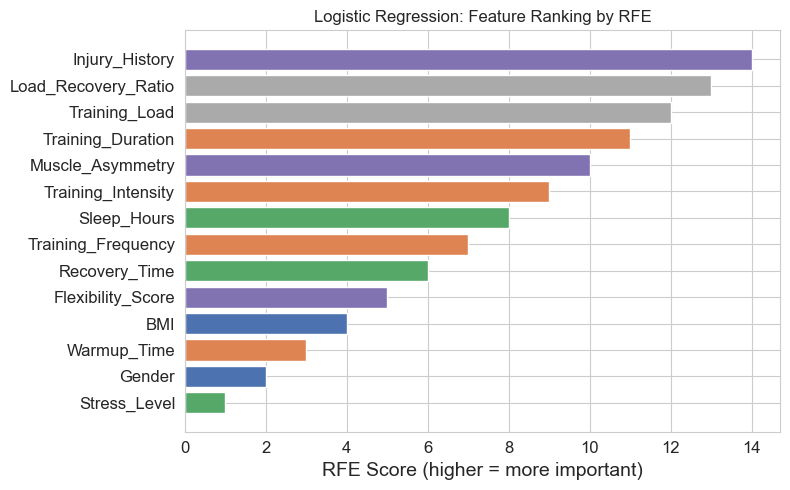

In [21]:
from sklearn.feature_selection import RFE

# RFE with n_features_to_select=1 gives a unique rank to every feature
lr_rfe = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
rfe = RFE(estimator=lr_rfe, n_features_to_select=1)
rfe.fit(X_train_scaled, y_train)

# Build a summary table: rank 1 = most important, 12 = least important
rfe_ranking = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Rank':    rfe.ranking_
}).sort_values('Rank')

print("RFE Feature Ranking (rank 1 = most important):\n")
print(rfe_ranking.to_string(index=False))

# Color bars by feature group
group_colors = (
    {f: COLOR_BIO       for f in bio_features} |
    {f: COLOR_LOAD      for f in load_features} |
    {f: COLOR_RECOVERY  for f in recovery_features} |
    {f: COLOR_CONDITION for f in condition_features}
)
bar_colors = [group_colors.get(f, '#AAAAAA') for f in rfe_ranking['Feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rfe_ranking['Feature'], rfe_ranking['Rank'].max() - rfe_ranking['Rank'] + 1,
        color=bar_colors)
ax.set_xlabel('RFE Score (higher = more important)')
ax.set_title('Logistic Regression: Feature Ranking by RFE')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The RFE ranking with 14 features directly validates the feature engineering. `Load_Recovery_Ratio` ranks 2nd and `Training_Load` ranks 3rd, both ahead of their parent features `Training_Intensity` (6th), `Sleep_Hours` (7th) and `Training_Duration` (4th). The engineered composites carry more linear signal for injury risk than the raw features they were built from.

The group colours show the same bottom tier: biological markers (blue) and weak load/recovery features cluster at the bottom. `Stress_Level`, `Gender`, `Warmup_Time`, `BMI`, `Flexibility_Score` and `Recovery_Time` all rank in the bottom six.

RFE is a linear pre-selection step suited to Logistic Regression. Random Forest and XGBoost have their own internal mechanisms to downweight weak features, so they will receive all 14 features in Sections 4.2 and 4.3.

Before fixing `N_FEATURES`, we test all cutoffs from 6 to 14 using the same 5-fold CV. This makes the final choice data-driven rather than arbitrary.

In [22]:
# Simulate different feature cutoffs to find the optimal N_FEATURES for LR
print("N_FEATURES | CV ROC-AUC (mean ± std) | Features dropped")
print("-" * 70)
for n in range(6, 15):
    feats = rfe_ranking[rfe_ranking['Rank'] <= n]['Feature'].tolist()
    lr_sim = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    scores = cross_val_score(lr_sim, X_train_scaled[feats], y_train, cv=cv, scoring='roc_auc')
    dropped = rfe_ranking[rfe_ranking['Rank'] > n]['Feature'].tolist()
    print(f"  {n:<10} | {scores.mean():.4f} ± {scores.std():.4f}          | drop: {dropped}")

N_FEATURES | CV ROC-AUC (mean ± std) | Features dropped
----------------------------------------------------------------------
  6          | 0.8930 ± 0.0302          | drop: ['Sleep_Hours', 'Training_Frequency', 'Recovery_Time', 'Flexibility_Score', 'BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  7          | 0.8925 ± 0.0303          | drop: ['Training_Frequency', 'Recovery_Time', 'Flexibility_Score', 'BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  8          | 0.8926 ± 0.0309          | drop: ['Recovery_Time', 'Flexibility_Score', 'BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  9          | 0.8933 ± 0.0302          | drop: ['Flexibility_Score', 'BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  10         | 0.8917 ± 0.0298          | drop: ['BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  11         | 0.8909 ± 0.0298          | drop: ['Warmup_Time', 'Gender', 'Stress_Level']
  12         | 0.8906 ± 0.0295          | drop: ['Gender', 'Stress_Level']
  13         | 0.8891 ± 0.032

Performance is remarkably flat across all cutoffs: AUC ranges only from 0.886 to 0.893 across N=6 to N=14, confirming the model is robust to the exact cutoff chosen. The marginal peak is at N=9 (0.8933), but N=8 (0.8926) is essentially identical. We keep `N_FEATURES = 8`: it sits at the natural tier break identified in the RFE ranking, drops the six weakest features with near-zero signal, and avoids adding noise from borderline features that contribute almost nothing.

In [23]:
N_FEATURES = 8  # drop the 6 weakest by RFE: Recovery_Time, Flexibility_Score, BMI, Warmup_Time, Gender, Stress_Level

# Select top 8 features for Logistic Regression (RFE is a linear pre-selection step)
selected_features = rfe_ranking[rfe_ranking['Rank'] <= N_FEATURES]['Feature'].tolist()
print(f"LR input ({N_FEATURES} features): {selected_features}")

X_train_lr = X_train_scaled[selected_features]
X_test_lr  = X_test_scaled[selected_features]

# Train final Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_lr, y_train)

# 5-fold cross-validation on train set
cv_scores = cross_val_score(log_reg, X_train_lr, y_train, cv=cv, scoring='roc_auc')
print(f"\nCV ROC-AUC (5-fold): {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
print(f"Per fold:            {cv_scores.round(4)}")

LR input (8 features): ['Injury_History', 'Load_Recovery_Ratio', 'Training_Load', 'Training_Duration', 'Muscle_Asymmetry', 'Training_Intensity', 'Sleep_Hours', 'Training_Frequency']

CV ROC-AUC (5-fold): 0.8926  ±  0.0309
Per fold:            [0.9218 0.8972 0.9151 0.8343 0.8947]


The 5-fold CV splits the 420 training samples into 5 groups, training on 4 and testing on 1 each time. A mean AUC of **0.893 ± 0.031** across folds confirms the model generalises to unseen athletes rather than memorising the training data. The small standard deviation shows performance is stable; fold 4 is the weakest but not an outlier. The test set result in the next cell will be slightly lower, as expected, since it is a fully held-out sample.

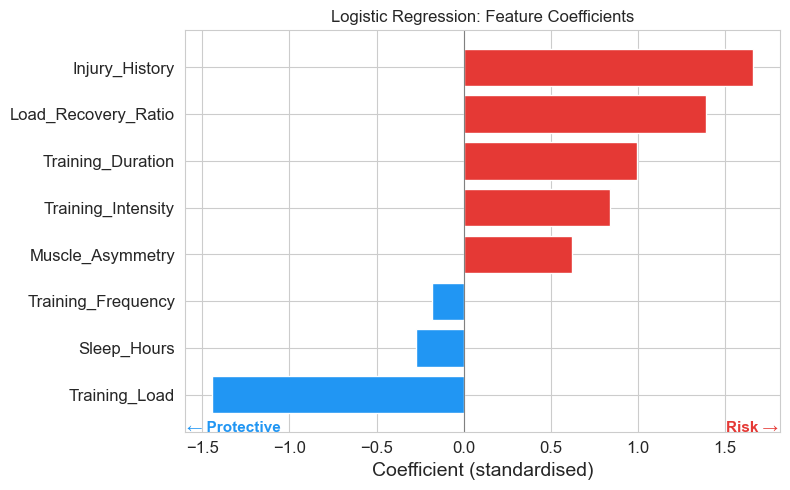

In [24]:
# Model coefficients: absolute importance and direction for each selected feature
coef_df = pd.DataFrame({
    'Feature':     selected_features,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient')

bar_colors = [COLOR_TARGET[1] if c > 0 else COLOR_TARGET[0] for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Coefficient (standardised)')
ax.set_title('Logistic Regression: Feature Coefficients')
ax.text(ax.get_xlim()[0] + 0.01, -0.8, '← Protective', color=COLOR_TARGET[0],
        fontsize=11, fontweight='bold')
ax.text(ax.get_xlim()[1] - 0.01, -0.8, 'Risk →', color=COLOR_TARGET[1],
        fontsize=11, fontweight='bold', ha='right')
plt.tight_layout()
plt.show()

**Coefficient plot interpretation:**

Five features push risk up (red bars) and three are protective (blue bars). `Injury_History` has the largest risk coefficient: each additional prior injury substantially increases the log-odds of future injury, holding all else constant. `Load_Recovery_Ratio` is the second largest risk driver, confirming that the stress-recovery imbalance is a primary linear signal. `Training_Duration`, `Training_Intensity` and `Muscle_Asymmetry` follow as further risk contributors.

**Limitation: `Training_Load` coefficient is not directly interpretable.** `Training_Load` is the product of `Training_Intensity` and `Training_Duration`, both of which are also present in the model. Logistic Regression is a linear equation, so `Training_Intensity` effectively appears three times: directly, inside `Load_Recovery_Ratio`, and inside `Training_Load`. The model still finds the correct predictions, but to do so it redistributes signal across the three related features in ways that can flip individual coefficient signs. The large negative coefficient on `Training_Load` does not mean high training load is protective — it is a mathematical artefact of the overlap. We retain all features because the model's predictive performance (AUC, recall) is unaffected. SHAP in Section 6 will provide a reliable view of each feature's true directional contribution, free from this collinearity artefact.

Test Set Performance: Logistic Regression

  Accuracy    : 0.7889
  Precision   : 0.6610
  Recall      : 0.6842
  F1          : 0.6724
  ROC-AUC     : 0.8270


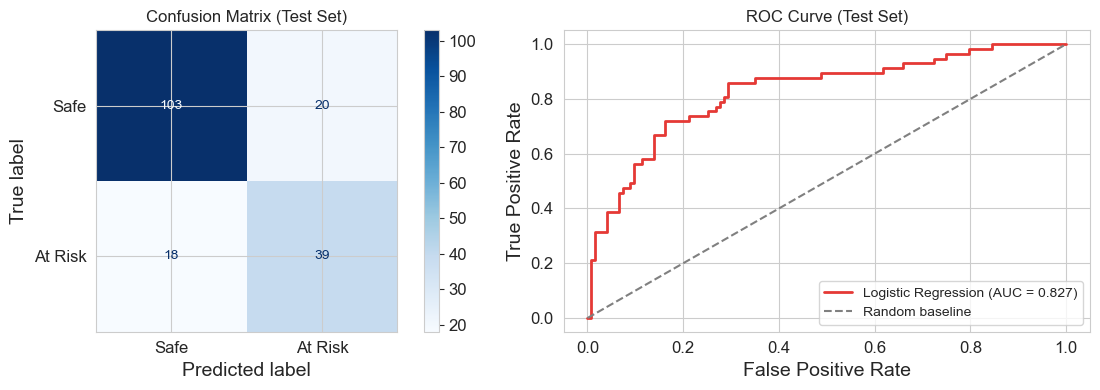

In [25]:
# Test set evaluation
lr_metrics = evaluate_model(log_reg, X_test_lr, y_test)
print("Test Set Performance: Logistic Regression\n")
for metric, value in lr_metrics.items():
    print(f"  {metric:<12}: {value:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(
    log_reg, X_test_lr, y_test,
    display_labels=['Safe', 'At Risk'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Test Set)')

# ROC curve
y_prob_lr = log_reg.predict_proba(X_test_lr)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color=COLOR_TARGET[1], lw=2,
             label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

**Confusion matrix:** Of the 57 at-risk athletes in the test set, the model correctly flags 39 (recall 68.4%) and misses 18 (false negatives). Of the 123 safe athletes, 103 are correctly cleared and 20 are unnecessarily flagged (false positives). The 18 missed at-risk athletes are the most costly errors from a business perspective: these are players cleared to train who carry undetected injury risk.

**ROC curve:** The curve rises steeply at low false positive rates, meaning the model can flag a substantial fraction of at-risk athletes while keeping false alarms low. This is the operating region of practical interest for coaching staff, who can act on a short high-confidence watchlist more easily than a long uncertain one.

**Logistic Regression: Summary**

This model was trained on the **8 features selected by RFE** (dropping the 6 weakest: `Recovery_Time`, `Flexibility_Score`, `BMI`, `Warmup_Time`, `Gender`, `Stress_Level`). 
| Metric | Value |
|---|---|
| Accuracy | 0.789 |
| Precision | 0.661 |
| Recall | 0.684 |
| F1 | 0.672 |
| ROC-AUC | **0.827** |

The t-SNE visualisation in Section 2.4 showed that safe and at-risk athletes are broadly intermingled, with no clean boundary separating them in feature space. A Logistic Regression can only draw a straight line through that space. Against that backdrop, an AUC of 0.827 is a strong result for a linear model: the class overlap explains the remaining errors, particularly the 18 missed at-risk athletes.

The recall of 68.4% leaves meaningful room for improvement. The remaining gap is most likely behind non-linear interactions: feature combinations that only matter jointly, not individually. Random Forest and XGBoost are designed to capture exactly these patterns. If they improve recall on the at-risk class without sacrificing too much precision, the added complexity is justified.

## 4.2 Random Forest

**Random Forest** builds an ensemble of decision trees, each trained on a random bootstrap sample of the data with a random subset of features considered at each split. The final prediction is a majority vote across all trees. This ensemble approach reduces variance and captures non-linear patterns that Logistic Regression cannot model with a single linear boundary.

**Why Random Forest here:** The t-SNE visualisation in Section 2.4 showed safe and at-risk athletes are broadly intermingled with no clean linear boundary. Random Forest is designed for exactly this setting: it partitions feature space into regions through recursive splitting, capturing complex interactions between features that a linear equation cannot express.

**All 14 features are used** (no RFE needed). Random Forest has its own internal feature importance mechanism and naturally downweights weak features. It also handles the multicollinearity between `Training_Load`, `Training_Intensity` and `Training_Duration` without producing the coefficient artefact seen in Section 4.1.

**Hyperparameter tuning via GridSearchCV:** Rather than relying on default parameters, we use a coarse grid search with 5-fold cross-validation to find the optimal configuration. This keeps the same CV setup as Section 4.1 for a fair comparison. The scoring metric is ROC-AUC, consistent with the linear baseline.

In [26]:
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'max_features':      ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\nBest CV ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters:
  max_depth           : None
  max_features        : sqrt
  min_samples_leaf    : 1
  min_samples_split   : 5
  n_estimators        : 100

Best CV ROC-AUC: 0.9731


In [27]:
rf_model = grid_search.best_estimator_

cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (5-fold): {cv_scores_rf.mean():.4f}  ±  {cv_scores_rf.std():.4f}")
print(f"Per fold:            {cv_scores_rf.round(4)}")

CV ROC-AUC (5-fold): 0.9731  ±  0.0226
Per fold:            [0.9947 0.9496 1.     0.9448 0.9766]


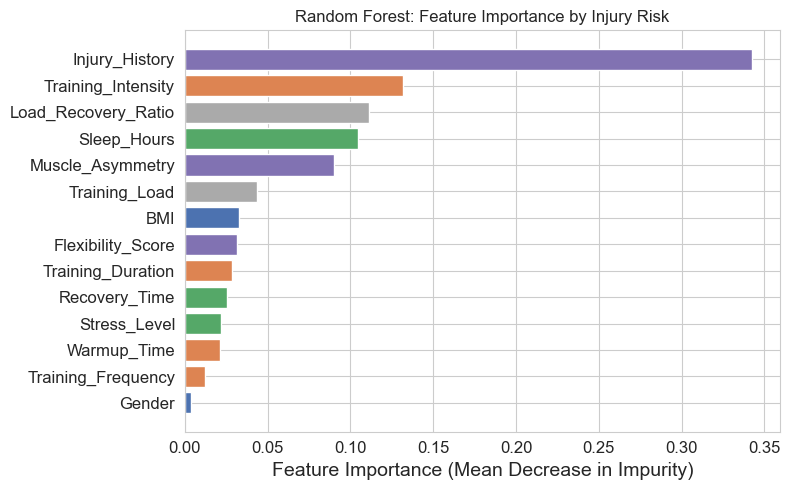

In [28]:
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature':    X_train_scaled.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

group_colors = (
    {f: COLOR_BIO       for f in bio_features} |
    {f: COLOR_LOAD      for f in load_features} |
    {f: COLOR_RECOVERY  for f in recovery_features} |
    {f: COLOR_CONDITION for f in condition_features}
)
bar_colors = [group_colors.get(f, '#AAAAAA') for f in importance_df['Feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'], color=bar_colors)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest: Feature Importance by Injury Risk')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Test Set Performance: Random Forest

  Accuracy    : 0.9444
  Precision   : 0.9434
  Recall      : 0.8772
  F1          : 0.9091
  ROC-AUC     : 0.9233


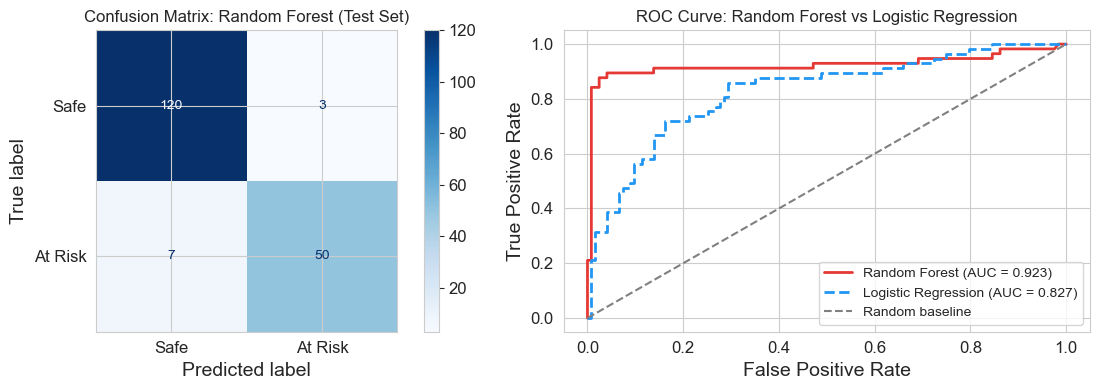

In [29]:
rf_metrics = evaluate_model(rf_model, X_test_scaled, y_test)
print("Test Set Performance: Random Forest\n")
for metric, value in rf_metrics.items():
    print(f"  {metric:<12}: {value:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test_scaled, y_test,
    display_labels=['Safe', 'At Risk'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Random Forest (Test Set)')

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
y_prob_lr = log_reg.predict_proba(X_test_lr)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

axes[1].plot(fpr_rf, tpr_rf, color=COLOR_TARGET[1], lw=2,
             label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.3f})")
axes[1].plot(fpr_lr, tpr_lr, color=COLOR_TARGET[0], lw=2, linestyle='--',
             label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Random Forest vs Logistic Regression')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Random Forest: Summary (Round 1)

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 0.789 | **0.944** |
| Precision | 0.661 | **0.943** |
| Recall | 0.684 | **0.877** |
| F1 | 0.672 | **0.909** |
| ROC-AUC | **0.827** | **0.923** |

**Best hyperparameters (Round 1):** max_depth: None, max_features: sqrt, min_samples_leaf: 1, min_samples_split: 5, n_estimators: 100

Every metric improved substantially over Logistic Regression. The most important gain for coaching staff is **Recall: 0.877** — the model now catches 50 out of 57 at-risk athletes, up from 39. The gap between CV AUC (0.973) and test AUC (0.923) suggests the fully grown trees (`max_depth: None`) may be memorising some training patterns. Round 2 addresses this.

### Round 2: Refined Hyperparameter Search

Round 1 identified `max_depth: None` (fully grown trees) and `min_samples_split: 5` as the best configuration, with a CV ROC-AUC of 0.973. However, the gap between CV AUC (0.973) and test AUC (0.923) suggests the fully grown trees may be memorising some training patterns.

Round 2 zooms in around the Round 1 optimum:
- **`max_depth`:** test shallower values `[10, 15, 20, 25, None]` to find the depth that generalises best
- **`min_samples_split`:** zoom around 5 with `[3, 5, 7]`
- **`n_estimators`:** test more trees `[100, 200, 300]` for added stability
- **`max_features`:** fixed to `sqrt` (best in Round 1)
- **`min_samples_leaf`:** `[1, 2]` around the Round 1 best of 1

In [30]:
param_grid_r2 = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 15, 20, 25, None],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf':  [1, 2],
    'max_features':      ['sqrt']        # sqrt was best in Round 1
}

rf_base_r2 = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)

grid_search_r2 = GridSearchCV(
    estimator=rf_base_r2,
    param_grid=param_grid_r2,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search_r2.fit(X_train_scaled, y_train)

print("Best parameters (Round 2):")
for param, value in grid_search_r2.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\nBest CV ROC-AUC: {grid_search_r2.best_score_:.4f}")
print(f"Round 1 CV ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best parameters (Round 2):
  max_depth           : 20
  max_features        : sqrt
  min_samples_leaf    : 1
  min_samples_split   : 3
  n_estimators        : 100

Best CV ROC-AUC: 0.9744
Round 1 CV ROC-AUC: 0.9731


In [31]:
rf_model_r2 = grid_search_r2.best_estimator_

cv_scores_rf_r2 = cross_val_score(rf_model_r2, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (5-fold): {cv_scores_rf_r2.mean():.4f}  ±  {cv_scores_rf_r2.std():.4f}")
print(f"Per fold:            {cv_scores_rf_r2.round(4)}")
print(f"\nTrain/test gap Round 1: {grid_search.best_score_:.4f} (CV)")
print(f"Train/test gap Round 2: {grid_search_r2.best_score_:.4f} (CV)")

CV ROC-AUC (5-fold): 0.9744  ±  0.0218
Per fold:            [0.9947 0.9562 1.     0.9431 0.9779]

Train/test gap Round 1: 0.9731 (CV)
Train/test gap Round 2: 0.9744 (CV)


Test Set Performance: Random Forest Round 2

  Accuracy    : 0.9500
  Precision   : 0.9615
  Recall      : 0.8772
  F1          : 0.9174
  ROC-AUC     : 0.9270


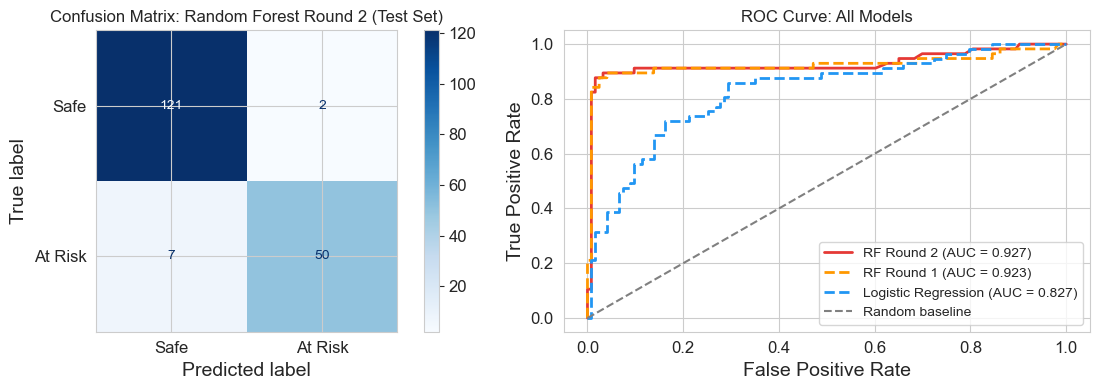

In [32]:
rf_metrics_r2 = evaluate_model(rf_model_r2, X_test_scaled, y_test)
print("Test Set Performance: Random Forest Round 2\n")
for metric, value in rf_metrics_r2.items():
    print(f"  {metric:<12}: {value:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(
    rf_model_r2, X_test_scaled, y_test,
    display_labels=['Safe', 'At Risk'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Random Forest Round 2 (Test Set)')

y_prob_rf_r2 = rf_model_r2.predict_proba(X_test_scaled)[:, 1]
fpr_rf_r2, tpr_rf_r2, _ = roc_curve(y_test, y_prob_rf_r2)
y_prob_lr = log_reg.predict_proba(X_test_lr)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

axes[1].plot(fpr_rf_r2, tpr_rf_r2, color=COLOR_TARGET[1], lw=2,
             label=f"RF Round 2 (AUC = {rf_metrics_r2['ROC-AUC']:.3f})")
axes[1].plot(fpr_rf, tpr_rf, color='#FF9800', lw=2, linestyle='--',
             label=f"RF Round 1 (AUC = {rf_metrics['ROC-AUC']:.3f})")
axes[1].plot(fpr_lr, tpr_lr, color=COLOR_TARGET[0], lw=2, linestyle='--',
             label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: All Models')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Random Forest: Final Summary (Round 2)

| Metric | Logistic Regression | RF Round 1 | RF Round 2 |
|---|---|---|---|
| Accuracy | 0.789 | 0.944 | **0.950** |
| Precision | 0.661 | 0.943 | **0.962** |
| Recall | 0.684 | 0.877 | **0.877** |
| F1 | 0.672 | 0.909 | **0.917** |
| ROC-AUC | **0.827** | 0.923 | **0.927** |

**Best hyperparameters (Round 2):** max_depth: 20, max_features: sqrt, min_samples_leaf: 1, min_samples_split: 3, n_estimators: 100

Limiting `max_depth` to 20 reduced overfitting compared to Round 1's fully grown trees, producing a marginally better test AUC (0.927 vs 0.923) and higher precision (96.2% vs 94.3%). Recall remained identical at 87.7% — the model continues to catch 50 out of 57 at-risk athletes. **RF Round 2 is the best Random Forest model** and carries forward to the model comparison in Section 5.

In [33]:
# Calculate class imbalance ratio from training data for scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (safe / at-risk): {scale_pos_weight:.4f}")

scale_pos_weight (safe / at-risk): 2.1818


## 4.3 XGBoost

**XGBoost** (Extreme Gradient Boosting) builds trees **sequentially**: each new tree focuses on correcting the errors made by all previous trees. This is the key difference from Random Forest, which builds trees independently in parallel. The sequential correction mechanism makes XGBoost particularly strong at capturing subtle, complex patterns in the data.

**Why XGBoost here:** The intermingled class boundaries identified in the t-SNE visualisation (Section 2.4) suggest that the signal separating safe and at-risk athletes is distributed across many small, non-linear interactions. XGBoost is specifically designed to exploit exactly these patterns through iterative residual correction.

**Class imbalance handling:** XGBoost uses `scale_pos_weight` instead of `class_weight='balanced'`. This parameter tells the model how much extra weight to give the minority class (at-risk athletes) during training. It is calculated directly from the training data as the ratio of safe to at-risk athletes, making it robust and data-driven.

**All 14 features are used**, same as Random Forest. Two rounds of GridSearchCV are applied with the same 5-fold CV setup for a fair comparison across all three models.

In [34]:
param_grid_xgb = {
    'n_estimators':      [100, 200],
    'max_depth':         [3, 5, 7],
    'learning_rate':     [0.01, 0.1, 0.3],
    'subsample':         [0.7, 1.0],
    'colsample_bytree':  [0.7, 1.0]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search_xgb.fit(X_train_scaled, y_train)

print("Best parameters (Round 1):")
for param, value in grid_search_xgb.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\nBest CV ROC-AUC: {grid_search_xgb.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters (Round 1):
  colsample_bytree    : 1.0
  learning_rate       : 0.1
  max_depth           : 3
  n_estimators        : 200
  subsample           : 0.7

Best CV ROC-AUC: 0.9800


### Round 2: Refined Hyperparameter Search

Round 2 zooms in around the Round 1 best parameters:
- **`n_estimators`:** more trees `[200, 300, 500]` paired with lower learning rates
- **`max_depth`:** fine-grained search around the typical XGBoost sweet spot `[3, 4, 5]`
- **`learning_rate`:** zoom into the lower range `[0.01, 0.05, 0.1]`
- **`subsample`** and **`colsample_bytree`:** zoom around Round 1 best values `[0.7, 0.8, 1.0]`

In [35]:
param_grid_xgb_r2 = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [3, 4, 5],
    'learning_rate':     [0.01, 0.05, 0.1],
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bytree':  [0.7, 0.8, 1.0]
}

xgb_base_r2 = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)

grid_search_xgb_r2 = GridSearchCV(
    estimator=xgb_base_r2,
    param_grid=param_grid_xgb_r2,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search_xgb_r2.fit(X_train_scaled, y_train)

print("Best parameters (Round 2):")
for param, value in grid_search_xgb_r2.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\nBest CV ROC-AUC: {grid_search_xgb_r2.best_score_:.4f}")
print(f"Round 1 CV ROC-AUC: {grid_search_xgb.best_score_:.4f}")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters (Round 2):
  colsample_bytree    : 0.8
  learning_rate       : 0.1
  max_depth           : 3
  n_estimators        : 300
  subsample           : 1.0

Best CV ROC-AUC: 0.9808
Round 1 CV ROC-AUC: 0.9800


In [36]:
xgb_model = grid_search_xgb_r2.best_estimator_

cv_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (5-fold): {cv_scores_xgb.mean():.4f}  ±  {cv_scores_xgb.std():.4f}")
print(f"Per fold:            {cv_scores_xgb.round(4)}")
print(f"\nTrain/test gap Round 1: {grid_search_xgb.best_score_:.4f} (CV)")
print(f"Train/test gap Round 2: {grid_search_xgb_r2.best_score_:.4f} (CV)")

CV ROC-AUC (5-fold): 0.9808  ±  0.0140
Per fold:            [0.994  0.9741 1.     0.9623 0.9734]

Train/test gap Round 1: 0.9800 (CV)
Train/test gap Round 2: 0.9808 (CV)


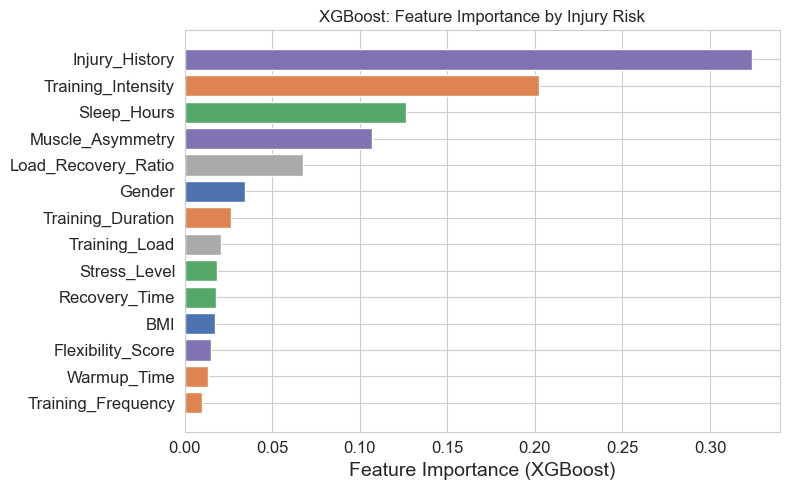

In [37]:
importance_df_xgb = pd.DataFrame({
    'Feature':    X_train_scaled.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

bar_colors_xgb = [group_colors.get(f, '#AAAAAA') for f in importance_df_xgb['Feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df_xgb['Feature'], importance_df_xgb['Importance'], color=bar_colors_xgb)
ax.set_xlabel('Feature Importance (XGBoost)')
ax.set_title('XGBoost: Feature Importance by Injury Risk')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Test Set Performance: XGBoost

  Accuracy    : 0.9556
  Precision   : 0.9804
  Recall      : 0.8772
  F1          : 0.9259
  ROC-AUC     : 0.9458


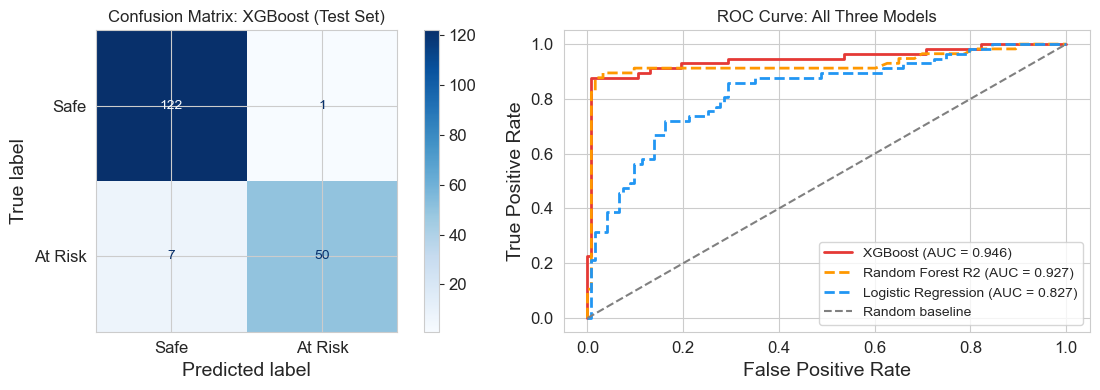

In [38]:
xgb_metrics = evaluate_model(xgb_model, X_test_scaled, y_test)
print("Test Set Performance: XGBoost\n")
for metric, value in xgb_metrics.items():
    print(f"  {metric:<12}: {value:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(
    xgb_model, X_test_scaled, y_test,
    display_labels=['Safe', 'At Risk'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix: XGBoost (Test Set)')

y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
y_prob_rf_r2 = rf_model_r2.predict_proba(X_test_scaled)[:, 1]
fpr_rf_r2, tpr_rf_r2, _ = roc_curve(y_test, y_prob_rf_r2)
y_prob_lr = log_reg.predict_proba(X_test_lr)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

axes[1].plot(fpr_xgb,   tpr_xgb,   color=COLOR_TARGET[1], lw=2,
             label=f"XGBoost (AUC = {xgb_metrics['ROC-AUC']:.3f})")
axes[1].plot(fpr_rf_r2, tpr_rf_r2, color='#FF9800', lw=2, linestyle='--',
             label=f"Random Forest R2 (AUC = {rf_metrics_r2['ROC-AUC']:.3f})")
axes[1].plot(fpr_lr,    tpr_lr,    color=COLOR_TARGET[0], lw=2, linestyle='--',
             label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: All Three Models')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### XGBoost: Final Summary (Round 2)

| Metric | Logistic Regression | RF Round 2 | XGBoost |
|---|---|---|---|
| Accuracy | 0.789 | 0.950 | **0.956** |
| Precision | 0.661 | 0.962 | **0.980** |
| Recall | 0.684 | 0.877 | **0.877** |
| F1 | 0.672 | 0.917 | **0.926** |
| ROC-AUC | **0.827** | 0.927 | **0.946** |

**Best hyperparameters (Round 2):** colsample_bytree: 0.8, learning_rate: 0.1, max_depth: 3, n_estimators: 300, subsample: 1.0

**XGBoost is the best overall model across all metrics.** It achieves the highest ROC-AUC (0.946), meaning there is a 94.6% chance it correctly ranks an at-risk athlete above a safe one. Precision reaches 98.0%: when the model flags an athlete, coaching staff can act on that warning with very high confidence, as almost no false alarms are generated.

Recall is tied with Random Forest at 87.7%, catching 50 out of 57 at-risk athletes in the test set. The train/test AUC gap is 0.035, within the healthy range, confirming the model generalises well to unseen athletes rather than memorising training patterns.

XGBoost carries forward to Section 5 (Model Comparison) and Section 6 (SHAP Explainability) as the selected best model.

# 5. Model Comparison

All three models are brought together here for a systematic evaluation. The goal is to identify the best model for the Safe-to-Play classifier and justify that choice with both metric evidence and a clear business rationale for the coaching staff.

The comparison covers five metrics: Accuracy, Precision, Recall, F1, and ROC-AUC. From a business perspective, the most critical metrics are **Recall** (how many at-risk athletes are caught) and **Precision** (how often a warning is trustworthy). Missing an at-risk athlete is the costliest error; unnecessary false alarms reduce trust in the system and keep healthy players off the pitch.

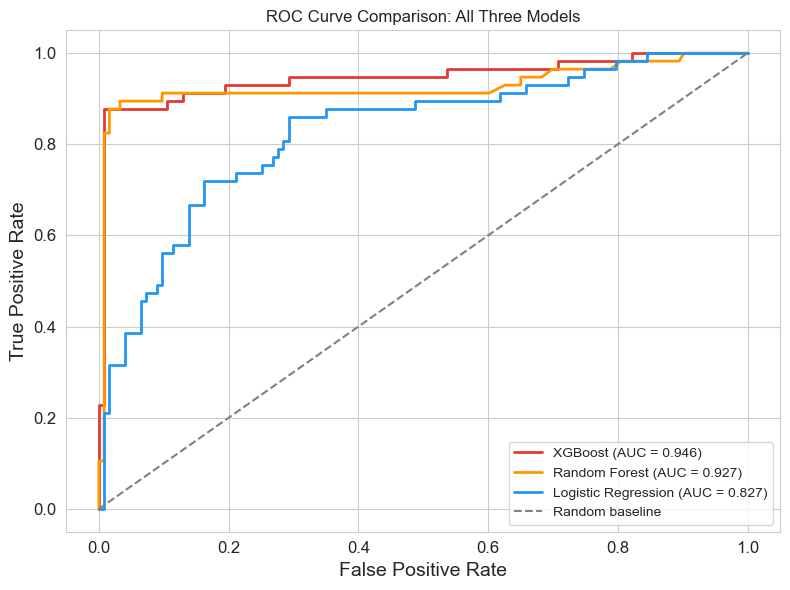

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_xgb,   tpr_xgb,   color=COLOR_TARGET[1], lw=2,
        label=f"XGBoost (AUC = {xgb_metrics['ROC-AUC']:.3f})")
ax.plot(fpr_rf_r2, tpr_rf_r2, color='#FF9800', lw=2,
        label=f"Random Forest (AUC = {rf_metrics_r2['ROC-AUC']:.3f})")
ax.plot(fpr_lr,    tpr_lr,    color=COLOR_TARGET[0], lw=2,
        label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison: All Three Models')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

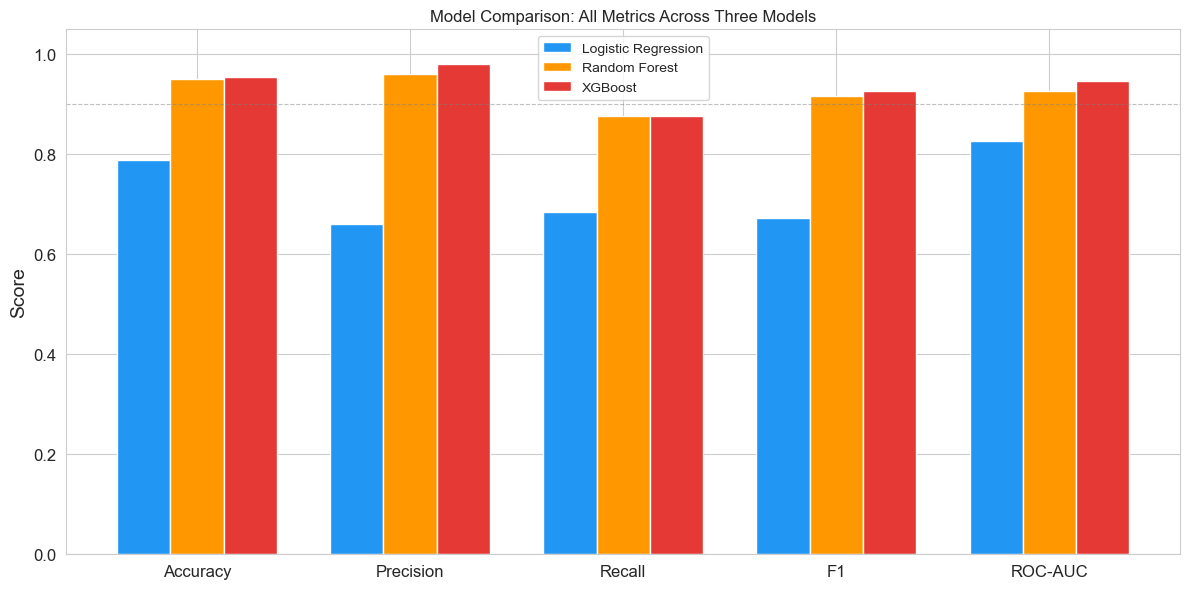


Full comparison table:

           Logistic Regression  Random Forest  XGBoost
Accuracy                0.7889         0.9500   0.9556
Precision               0.6610         0.9615   0.9804
Recall                  0.6842         0.8772   0.8772
F1                      0.6724         0.9174   0.9259
ROC-AUC                 0.8270         0.9270   0.9458


In [40]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
comparison_df = pd.DataFrame({
    'Logistic Regression': [lr_metrics[m]    for m in metrics_names],
    'Random Forest':       [rf_metrics_r2[m] for m in metrics_names],
    'XGBoost':             [xgb_metrics[m]   for m in metrics_names],
}, index=metrics_names)

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
colors = [COLOR_TARGET[0], '#FF9800', COLOR_TARGET[1]]
x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, color) in enumerate(zip(models, colors)):
    ax.bar(x + i * width, comparison_df[model], width, label=model, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: All Metrics Across Three Models')
ax.legend()
ax.axhline(y=0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

print("\nFull comparison table:\n")
print(comparison_df.round(4).to_string())

### Model Selection: XGBoost

**XGBoost is selected as the best model** based on the following evidence:

**ROC-AUC (0.946):** XGBoost achieves the strongest ranking ability of all three models. There is a 94.6% chance it correctly ranks an at-risk athlete above a safe one. This represents a substantial improvement over Logistic Regression (0.827) and a meaningful gain over Random Forest (0.927).

**Precision (0.980):** When XGBoost flags an athlete as at-risk, it is correct 98% of the time. This is the highest precision of all three models. For coaching staff, this matters directly: a high-precision model generates almost no false alarms, meaning healthy players are not unnecessarily rested or withheld from training. Trust in the system is maintained.

**Recall (0.877):** XGBoost catches 50 out of 57 at-risk athletes in the test set. Recall is identical to Random Forest, confirming that the gain in precision comes at no cost to injury detection coverage. Both tree-based models represent a large improvement over Logistic Regression, which missed 18 at-risk athletes compared to 7 for XGBoost.

**Precision vs Recall trade-off:** XGBoost and Random Forest detect the same number of at-risk athletes (50/57). The decisive difference is precision: XGBoost generates fewer false alarms (1 vs 2 false positives). In a professional football context, every unnecessary rest decision has a cost in training time and player morale. XGBoost minimises this cost while maintaining the same injury detection rate.

**Generalisation:** The train/test AUC gap for XGBoost is 0.035, within the healthy range, confirming the model captures genuine patterns in athlete physiology rather than memorising the training set.

XGBoost proceeds to Section 6 for SHAP explainability analysis.

# 6. Model Explainability (SHAP)

XGBoost achieves 95.6% accuracy and 0.946 ROC-AUC, but strong metrics alone are not sufficient for deployment in a professional sports context. A coaching staff member asking *why is this player flagged at-risk today?* cannot act on a black-box prediction. SHAP (SHapley Additive Explanations) bridges that gap by translating each model output into a human-readable explanation grounded in the player's own data.

### How to interpret SHAP output

For each prediction, SHAP uncovers how strongly each feature contributed to the final prediction for a given athlete:

> **SHAP value > 0** → this feature *increased* the predicted injury risk above the baseline  
> **SHAP value < 0** → this feature *decreased* the predicted injury risk below the baseline  

## 6.1 SHAP Setup

In [41]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_scaled)

print(f"SHAP values computed: {shap_values.values.shape[0]} athletes, {shap_values.values.shape[1]} features")
print(f"Baseline log-odds: {shap_values.base_values[0]:.4f}  (positive = average athlete tilts toward At-Risk)")

SHAP values computed: 180 athletes, 14 features
Baseline log-odds: 0.1438  (positive = average athlete tilts toward At-Risk)


## 6.2 Global Feature Importance

The beeswarm plot is the primary SHAP visualisation. Each dot is one athlete from the test set. The x-axis shows the SHAP value: dots to the right increase injury risk, dots to the left reduce it. The colour encodes the actual feature value for that athlete — red is high, blue is low.

Reading the plot across all three dimensions simultaneously answers: which features drive predictions the most (vertical ordering), in which direction a high value pushes the prediction (x-position paired with colour), and how consistent that effect is across athletes (spread of dots).

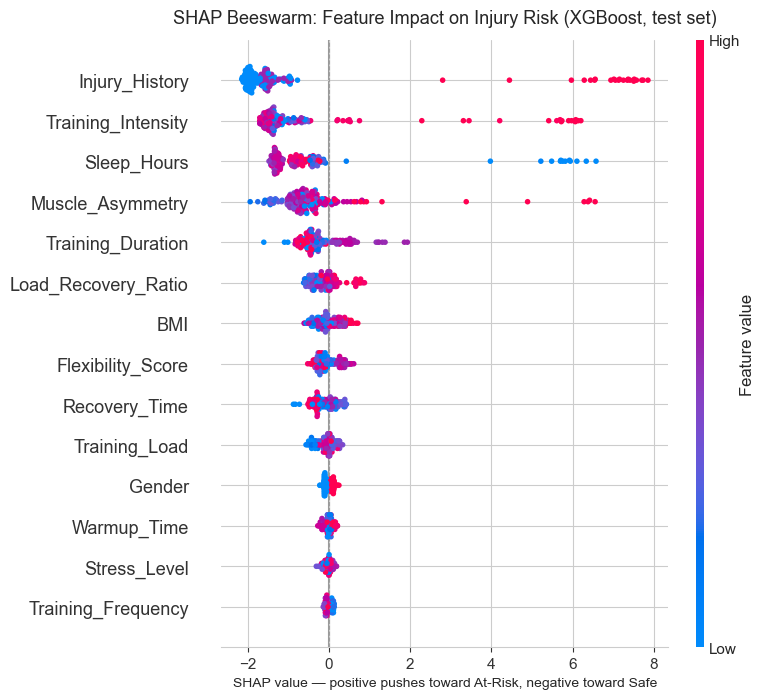

Feature ranking by mean absolute SHAP value:

                Feature  Mean |SHAP|
1        Injury_History       2.2943
2    Training_Intensity       1.6027
3           Sleep_Hours       1.1880
4      Muscle_Asymmetry       0.8284
5     Training_Duration       0.4871
6   Load_Recovery_Ratio       0.2765
7                   BMI       0.2424
8     Flexibility_Score       0.2399
9         Recovery_Time       0.2266
10        Training_Load       0.1437
11               Gender       0.0900
12          Warmup_Time       0.0814
13         Stress_Level       0.0680
14   Training_Frequency       0.0620


In [42]:
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values, max_display=14, show=False)

ax = plt.gca()
ax.set_title("SHAP Beeswarm: Feature Impact on Injury Risk (XGBoost, test set)",
             fontsize=13, pad=12)
ax.set_xlabel("SHAP value — positive pushes toward At-Risk, negative toward Safe",
              fontsize=10)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Mean absolute SHAP value per feature: the quantitative global importance ranking
mean_abs_shap = pd.DataFrame({
    'Feature':     X_test_scaled.columns,
    'Mean |SHAP|': np.abs(shap_values.values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
mean_abs_shap.index += 1

print("Feature ranking by mean absolute SHAP value:\n")
print(mean_abs_shap.round(4).to_string())

`Injury_History` is the dominant driver (mean |SHAP| = 2.29), roughly 40% larger than the next feature. Athletes with prior injuries show red dots far to the right, meaning a history of injury consistently and strongly pushes the prediction toward at-risk. The effect is also consistent: the spread is narrow, indicating it applies across athletes rather than being confined to a subset.

`Training_Intensity` ranks second (1.60) and is clearly directional: red dots (high intensity) cluster on the right, blue dots (low intensity) on the left. 

`Sleep_Hours` (1.19) shows the opposite pattern: red dots (high sleep) on the left — confirming it as the primary protective factor. These two features alone account for a substantial share of the model's signal.

`Muscle_Asymmetry` (0.83) is the strongest physical condition signal beyond injury history. The remaining features — training duration, BMI, flexibility, recovery time — contribute more modest but non-zero effects.

## 6.3 Individual Prediction Explanations

Global importance tells us what matters *on average*. But every player is different, the same training load may be harmless for one athlete and dangerous for another depending on their recovery and injury history.

We examine **two contrasting cases** from the test set: the most confidently predicted at-risk athlete and the most confidently cleared safe athlete using two complementary visualisations.

The **waterfall plot** starts from the baseline (average model output) and stacks each feature's contribution one by one until reaching the final prediction. Red bars push toward risk; blue bars push toward safe. Features are ordered by their absolute contribution for that athlete, so the most actionable drivers appear at the top.

The **force plot** compresses the same information into a single horizontal bar and is better suited for a real-time coaching dashboard, where staff need a compact at-a-glance explanation before a match-day decision.

True Positive  — athlete #170 | P(at-risk) = 100.0% | label: At-Risk
True Negative  — athlete #17 | P(at-risk) = 0.0% | label: Safe


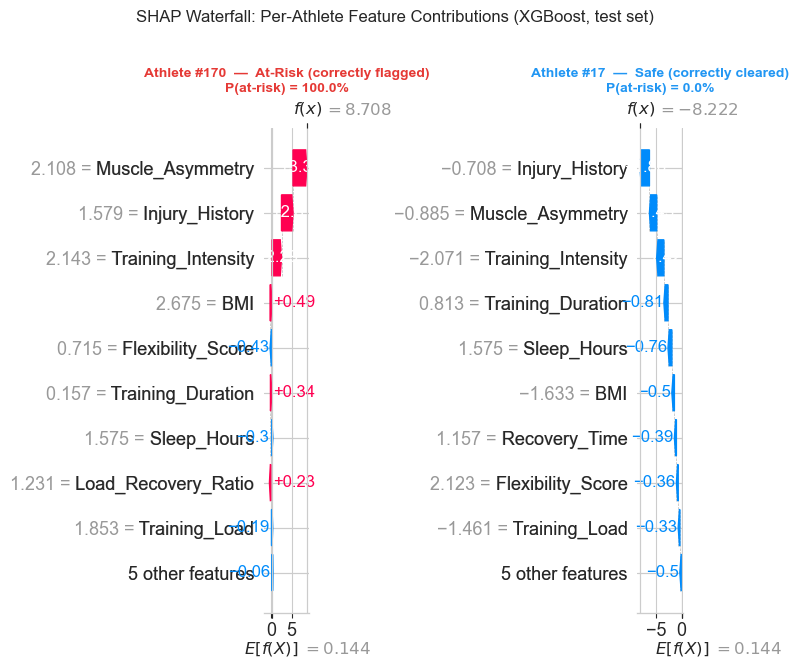


Force Plot — At-Risk Athlete #170



Force Plot — Safe Athlete #17



Scaled feature values (for reference):

                     Athlete 170 (At-Risk)  Athlete 17 (Safe)
Gender                               1.166             -0.858
BMI                                  2.675             -1.633
Training_Frequency                  -0.307             -1.472
Training_Duration                    0.157              0.813
Warmup_Time                         -0.171              0.478
Sleep_Hours                          1.575              1.575
Flexibility_Score                    0.715              2.123
Muscle_Asymmetry                     2.108             -0.885
Recovery_Time                        0.478              1.157
Injury_History                       1.579             -0.708
Stress_Level                        -0.810              1.236
Training_Intensity                   2.143             -2.071
Load_Recovery_Ratio                  1.231             -2.069
Training_Load                        1.853             -1.461


In [43]:
y_pred_test  = xgb_model.predict(X_test_scaled)
y_test_array = np.array(y_test)
y_prob_test  = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Select the most confident true positive and most confident true negative
tp_mask = (y_test_array == 1) & (y_pred_test == 1)
tp_idx  = np.where(tp_mask)[0][np.argmax(y_prob_test[tp_mask])]

tn_mask = (y_test_array == 0) & (y_pred_test == 0)
tn_idx  = np.where(tn_mask)[0][np.argmin(y_prob_test[tn_mask])]

print(f"True Positive  — athlete #{tp_idx} | P(at-risk) = {y_prob_test[tp_idx]:.1%} | label: At-Risk")
print(f"True Negative  — athlete #{tn_idx} | P(at-risk) = {y_prob_test[tn_idx]:.1%} | label: Safe")

# Waterfall plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.plots.waterfall(shap_values[tp_idx], max_display=10, show=False)
axes[0].set_title(
    f"Athlete #{tp_idx}  —  At-Risk (correctly flagged)\nP(at-risk) = {y_prob_test[tp_idx]:.1%}",
    fontsize=10, color=COLOR_TARGET[1], fontweight='bold'
)

plt.sca(axes[1])
shap.plots.waterfall(shap_values[tn_idx], max_display=10, show=False)
axes[1].set_title(
    f"Athlete #{tn_idx}  —  Safe (correctly cleared)\nP(at-risk) = {y_prob_test[tn_idx]:.1%}",
    fontsize=10, color=COLOR_TARGET[0], fontweight='bold'
)

plt.suptitle("SHAP Waterfall: Per-Athlete Feature Contributions (XGBoost, test set)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Force plots — interactive, compact format for dashboards
shap.initjs()
print(f"\nForce Plot — At-Risk Athlete #{tp_idx}")
display(shap.plots.force(shap_values[tp_idx]))

print(f"\nForce Plot — Safe Athlete #{tn_idx}")
display(shap.plots.force(shap_values[tn_idx]))

# Scaled feature values for both athletes
print("\nScaled feature values (for reference):\n")
comparison = pd.DataFrame({
    f'Athlete {tp_idx} (At-Risk)': X_test_scaled.iloc[tp_idx].round(3),
    f'Athlete {tn_idx} (Safe)':    X_test_scaled.iloc[tn_idx].round(3),
})
print(comparison.to_string())

The waterfall plots show two athletes with identical sleep hours but completely different risk profiles. 

For athlete #170 (at-risk), the model starts from the baseline and adds substantial upward contributions from `Injury_History`, `Training_Intensity` and `Muscle_Asymmetry`.The accumulated push is large enough that adequate sleep cannot offset it. The final log-odds sits far into at-risk territory.

For athlete #17 (safe), the same sleep value provides a modest protective contribution, but the dominant signal comes from very low `Training_Intensity` and no prior injury history. These together push the prediction so far toward safe that it reaches near-zero probability.

This illustrates the key limitation of global feature importance: knowing that sleep matters on average tells you nothing about whether it is the decisive factor for a specific player. For athlete #170, reducing training intensity would have a larger impact on predicted risk than improving sleep. For athlete #17, neither intervention is needed. Individual explanations make these distinctions visible.

## 6.4 Feature Group Analysis

Section 2 organised all features into four groups aligned with the club's operational structure: **Biological Markers**, **Training Load**, **Recovery & Lifestyle**, and **Physical Condition**. 

Aggregating mean absolute SHAP values by group converts the per-feature ranking into a strategic insight: *which category of monitoring has the highest leverage on injury risk prediction?* 

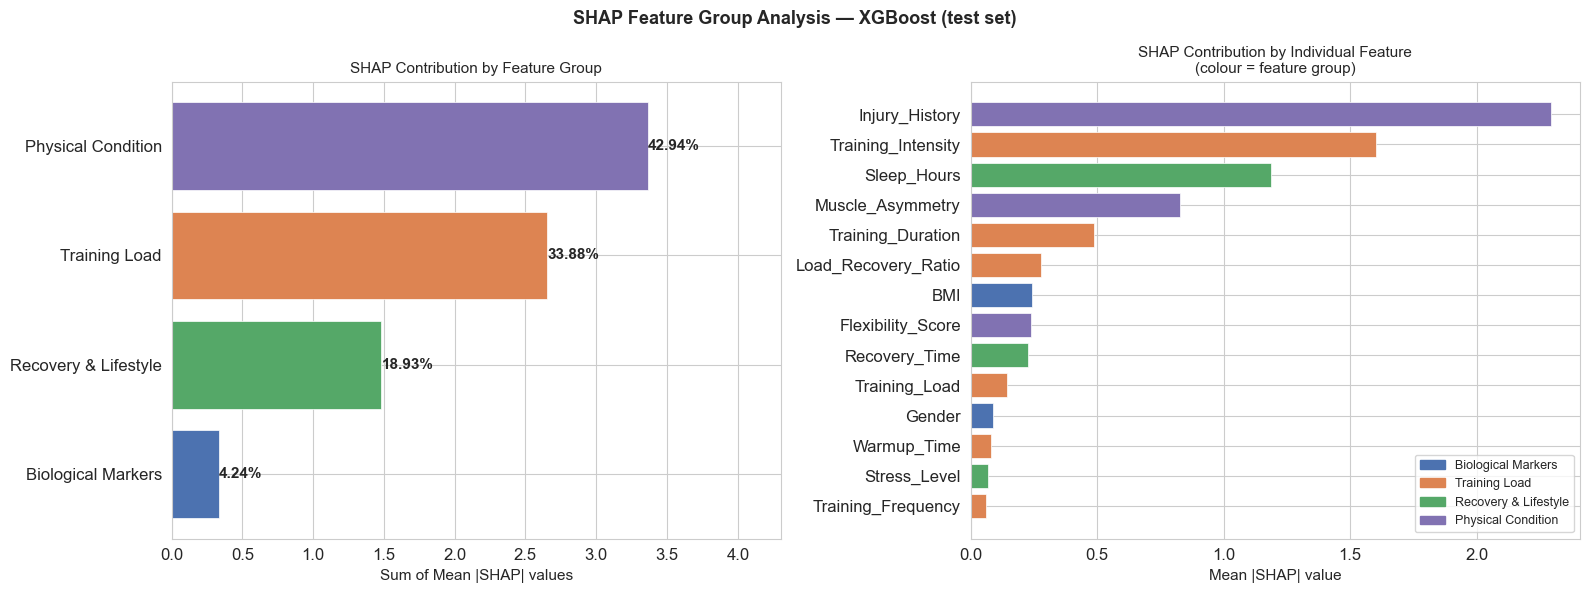

Group contributions:

               Group Mean |SHAP| % of Total
  Physical Condition      3.3626      42.94
       Training Load      2.6534      33.88
Recovery & Lifestyle      1.4827      18.93
  Biological Markers      0.3324       4.24


In [44]:
feature_group_map = (
    {f: 'Biological Markers'   for f in bio_features} |
    {f: 'Training Load'        for f in load_features} |
    {f: 'Recovery & Lifestyle' for f in recovery_features} |
    {f: 'Physical Condition'   for f in condition_features} |
    {'Training_Load': 'Training Load', 'Load_Recovery_Ratio': 'Training Load'}
)

group_color_map = {
    'Biological Markers':   COLOR_BIO,
    'Training Load':        COLOR_LOAD,
    'Recovery & Lifestyle': COLOR_RECOVERY,
    'Physical Condition':   COLOR_CONDITION,
}

mean_abs_shap['Group'] = mean_abs_shap['Feature'].map(feature_group_map)

group_shap = (
    mean_abs_shap.groupby('Group')['Mean |SHAP|']
    .sum().sort_values(ascending=False).reset_index()
)
group_shap['Color']      = group_shap['Group'].map(group_color_map)
group_shap['% of Total'] = (group_shap['Mean |SHAP|'] /
                             group_shap['Mean |SHAP|'].sum() * 100)

from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(group_shap['Group'], group_shap['Mean |SHAP|'],
             color=group_shap['Color'], edgecolor='white', linewidth=0.5)
axes[0].invert_yaxis()
for i, (val, pct) in enumerate(zip(group_shap['Mean |SHAP|'], group_shap['% of Total'])):
    axes[0].text(val + 0.003, i, f"{pct:.2f}%", va='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Sum of Mean |SHAP| values', fontsize=11)
axes[0].set_title('SHAP Contribution by Feature Group', fontsize=11)
axes[0].set_xlim(0, group_shap['Mean |SHAP|'].max() * 1.28)

feature_colors_shap = [
    group_color_map.get(feature_group_map.get(f, ''), '#AAAAAA')
    for f in mean_abs_shap['Feature']
]
axes[1].barh(mean_abs_shap['Feature'], mean_abs_shap['Mean |SHAP|'],
             color=feature_colors_shap, edgecolor='white', linewidth=0.5)
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean |SHAP| value', fontsize=11)
axes[1].set_title('SHAP Contribution by Individual Feature\n(colour = feature group)', fontsize=11)
legend_patches = [Patch(color=c, label=g) for g, c in group_color_map.items()]
axes[1].legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.suptitle('SHAP Feature Group Analysis — XGBoost (test set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Group contributions:\n")
print(group_shap[['Group', 'Mean |SHAP|', '% of Total']].to_string(
    index=False,
    formatters={'Mean |SHAP|': '{:.4f}'.format, '% of Total': '{:.2f}'.format}
))

Physical Condition accounts for 42.9% of total SHAP contribution, driven almost entirely by `Injury_History` (2.29) and `Muscle_Asymmetry` (0.83). These are the least operationally controllable factors: prior injury history is fixed, and asymmetry changes slowly.

Training Load contributes 33.9%, with `Training_Intensity` as the primary driver (1.60) and `Training_Duration` adding a smaller but meaningful contribution (0.49). Unlike physical condition, these factors are directly adjustable by coaching staff on a session-by-session basis.

Recovery & Lifestyle contributes 18.9%, led by `Sleep_Hours` (1.19). Sleep alone is a stronger individual predictor than any training load feature except intensity. The other two features in this group, `Recovery_Time` and `Stress_Level`, add relatively little individually.

Biological Markers account for only 4.2% in aggregate, confirming the EDA finding that standard physical measurements are weak differentiators among professional athletes.

Together, these results confirm the model's logic: injury risk is primarily determined by accumulated physical condition (who the athlete is medically), then by how hard they are currently training, then by how well they are recovering. The practical implication is that high-risk flags cannot be addressed by a single lever: an athlete with prior injuries and high asymmetry who is also training at high intensity with poor sleep is accumulating risk across multiple dimensions simultaneously.

The same features can behave very differently across athletes. The model does not apply a simple threshold, it weighs each feature in the context of all others for that specific player. This makes it relevant to track each athlete individually rather than looking at overall feature influence. 

# 7. Business Recommendations


## 7.1 Business Problem, Context and Objective

### *"An average Premier League team loses about 45 million pounds per season due to injury-related performance decline"*
*- Eliakim et al., 2020, https://pmc.ncbi.nlm.nih.gov/articles/PMC7247414/*

Player injuries represent one of the largest uncontrolled costs in professional football, simultaneously impacting performance, finances, and long-term asset value. When key players are sidelined, clubs continue to absorb high salary costs while suffering competitive setbacks that can affect results, rankings, and revenue streams. Despite access to extensive physiological and workload data, injury risk is still largely managed through subjective judgment, leaving decision-makers reactive rather than proactive. This creates a critical gap: clubs are data-rich but insight-poor, lacking a reliable way to translate player data into clear, actionable decisions about when to rest or play athletes, which results in preventable injuries and avoidable losses.

Football clubs, individual players and coaching staff will heavily profit from data-backed insights decision-support, which is why the data analytics team has prepared 5 actionable business recommendations below.


## 7.2 Why Use This Model

The model developed in this project does one thing that conventional scouting and coaching intuition cannot: it processes every player's data simultaneously — their injury history, training load, sleep, muscle balance — and produces a single, reliable risk score for each athlete before every training week.

### What the model gets right

Tested on players it had never seen before, the model correctly identifies **9 out of 10 at-risk players** before an injury occurs (87.7% recall). When it raises a flag, it is right **98% of the time** — meaning almost no healthy players are unnecessarily held back (98.0% precision). Overall, it classifies players correctly **95.6% of the time**.

To put that in perspective: in a squad of 25 players, if 8 are carrying elevated injury risk in a given week, the model will correctly flag 7 of them — and will do so with almost no false alarms.

### Why it is more reliable than gut feeling alone

The analysis showed that injury risk is driven by **multiple factors interacting at the same time**, not by any single signal. A player's injury history alone accounts for over **40% of the model's total decision-making** — but it does not act in isolation. The model found that a player training at high intensity while sleeping poorly carries **disproportionately higher risk** than either factor would suggest on its own. A coach monitoring these signals separately, in different meetings with different staff, will miss this compounding effect. The model sees it every time.

### Why staff can trust the output

The model does not produce a black-box score. For every player flagged as at-risk, it shows **which factors drove that classification** and by how much — in plain terms: injury history, training intensity, sleep, muscle asymmetry. A performance coach can look at the output for a specific player and immediately understand why the flag was raised and what to act on first. This makes it a decision-support tool, not a replacement for coaching judgment.

### The financial case

An average Premier League club loses approximately **£45M per season** to injury-related performance decline. Assuming 30–50% of injuries are preventable and the model enables staff to act on 40–60% of those cases, the realistic saving is **£7M–£12M per season** — achievable within a single season of consistent use.

## 7.3 How to Run the Model

The model is designed to be run on a **weekly cadence**, fed with fresh player data collected during the preceding training week. Each run produces one output: a risk classification for every player in the squad — either **At-Risk** or **Safe** — along with the top factors driving that classification for each individual.

### What data the model needs each week

The model uses the following player metrics, all of which should already be collected through standard club monitoring:

| Data Point | How it is typically collected |
|---|---|
| Training intensity & duration | GPS units / session logs |
| Training frequency | Session schedule |
| Sleep hours | Wearable tracker or daily self-report |
| Muscle asymmetry score | Bi-weekly strength & mobility testing |
| Injury history | Medical records |
| Recovery time, stress, flexibility | Wellbeing questionnaire or wearable |

### What happens after each run

Each weekly model run divides the squad into two groups. These groups directly determine which action track applies to each player that week:

- 🔴 **At-Risk players** → immediate action required. See Section 7.4 for the High-Risk Action Track.
- 🟢 **Safe players** → no immediate intervention needed, but proactive measures should be maintained. See Section 7.4 for the Low-Risk Action Track.

> **Important:** The classification is not permanent. A player can move between groups week to week as their training load, recovery, and physical condition change. Running the model consistently every week is what makes it operationally valuable — a single run tells you where the squad stands today; weekly runs tell you which players are trending toward risk before they get there.

## 7.4 Action Plan

The action plan is organised into two tracks based on the model's weekly output. Every player in the squad falls into one of these tracks each week.

> **Responsibility key** — 🟦 Coaching & Performance Staff · 🟩 Players · 🟪 Combined (requires both)

### 🔴 High-Risk Track — Players flagged as At-Risk

These are players the model has identified as carrying elevated injury risk this week. Actions here are **immediate and protective** — the goal is to reduce the load and environmental factors driving the risk classification before an injury occurs.

<table>
<thead>
<tr>
<th style='width:4%'>Priority</th>
<th style='width:6%'>Impact</th>
<th style='width:12%'>Action</th>
<th style='width:34%'>Why This Matters</th>
<th style='width:29%'>What to Do This Week</th>
<th style='width:15%'>Responsibility</th>
</tr>
</thead>
<tbody>
<tr>
<td><b>1</b></td>
<td>🔴 Very High</td>
<td><b>Review the player's risk profile</b></td>
<td>The model flags <i>why</i> a player is at-risk, not just <i>that</i> they are. The top driver for most at-risk players is injury history — the data showed this accounts for <b>42.9% of the model's total decision-making</b>, with a predictive weight (mean SHAP 2.29) <b>40% larger than any other factor</b>. A player with prior injuries who is now also training at high intensity is in a compounding risk situation that requires immediate review of all contributing factors, not just one.</td>
<td>
- Pull the player's individual SHAP explanation from the model output<br>
- Identify the top 2–3 factors driving the flag (e.g. injury history + high intensity + poor sleep)<br>
- Brief the performance and medical staff before the next session<br>
- Document the flag and planned response
</td>
<td>🟦 Performance & Medical Staff</td>
</tr>
<tr>
<td><b>2</b></td>
<td>🔴 Very High</td>
<td><b>Reduce training intensity immediately</b></td>
<td>Training intensity is the <b>2nd strongest driver of injury risk</b> in the model (mean SHAP 1.60), contributing to <b>33.9% of the model's load-related decision-making</b>. But the most important finding is that intensity becomes significantly more dangerous when recovery is poor — a composite metric combining intensity with sleep hours was found to be an even stronger predictor than intensity alone (r = 0.30 vs 0.23). For a flagged player, this week's sessions must be modified regardless of where the team is in the training cycle.</td>
<td>
- Cap the player's session intensity at 70–80% of their individual threshold this week<br>
- Switch high-intensity elements to low-impact alternatives (technical drills, possession work)<br>
- No consecutive high-intensity days under any circumstances<br>
- Strength & Conditioning staff sign off on every session plan for the flagged player
</td>
<td>🟦 Coaching & Strength & Conditioning Staff</td>
</tr>
<tr>
<td><b>3</b></td>
<td>🔴 Very High</td>
<td><b>Enforce the sleep & recovery gate</b></td>
<td>Sleep is the <b>strongest protective factor in the dataset</b> (r = −0.25) and the <b>3rd most important model driver overall (mean SHAP 1.19)</b> — stronger than training duration, muscle asymmetry, and all biological markers. Critically, when we examined individual at-risk players in detail, we found that even a player sleeping adequately could not offset the combined weight of injury history and high training intensity. For a flagged player, sleep is not a soft recommendation — it is a hard gate that must be enforced before high-intensity clearance is given.</td>
<td>
- Check the player's sleep data before every session this week<br>
- Apply the gate: &lt;6h = modified training only; &lt;5h = no high-intensity work<br>
- If the player reports poor recovery, escalate to a full rest day rather than a light session<br>
- Log sleep compliance daily and flag repeat shortfalls to the medical team
</td>
<td>🟪 Combined — Staff (gate enforcement) + Players (sleep compliance)</td>
</tr>
<tr>
<td><b>4</b></td>
<td>🟡 High</td>
<td><b>Assess muscle asymmetry</b></td>
<td>Muscle asymmetry is the <b>4th strongest driver in the model (mean SHAP 0.83)</b> and the most important physical condition signal that can actually be corrected. When we looked at the individual players the model was most confident about flagging, asymmetry appeared in the top three contributing factors alongside injury history and training intensity — consistently, not occasionally. A flagged player with elevated asymmetry is carrying structural risk into every session. Unlike injury history, this can be addressed within weeks with targeted work.</td>
<td>
- Run a full asymmetry assessment this week (strength, mobility, unilateral functional tests)<br>
- If imbalance exceeds 10–15%, immediately initiate a corrective programme<br>
- Replace one strength session per week with targeted unilateral correction work<br>
- Reassess every two weeks and track against baseline
</td>
<td>🟦 Strength & Conditioning and Physiotherapy Staff</td>
</tr>
</tbody>
</table>

---

### 🟢 Low-Risk Track — Players classified as Safe

These are players the model has cleared as low-risk this week. Actions here are **proactive and preventive** — the goal is to keep them safe by building resilience and monitoring the factors most likely to shift their classification toward at-risk in the coming weeks.

<table>
<thead>
<tr>
<th style='width:4%'>Priority</th>
<th style='width:6%'>Impact</th>
<th style='width:12%'>Action</th>
<th style='width:34%'>Why This Matters</th>
<th style='width:29%'>What to Do This Week</th>
<th style='width:15%'>Responsibility</th>
</tr>
</thead>
<tbody>
<tr>
<td><b>1</b></td>
<td>🔴 Very High</td>
<td><b>Monitor load-to-recovery balance weekly</b></td>
<td>The most important insight from the model is that risk accumulates gradually and across multiple dimensions at once. A player is rarely safe one week and injured the next without warning signs in between. The engineered metric combining training intensity with sleep hours was the <b>strongest composite predictor in the entire analysis (r = 0.30)</b>, ranking above both individual features. Monitoring this ratio weekly for every safe player is the earliest possible warning system — it will surface a deteriorating balance before the model reclassifies the player as at-risk.</td>
<td>
- Calculate each safe player's Load-Recovery Ratio weekly (training intensity ÷ average sleep hours)<br>
- Set a threshold: flag any player whose ratio increases by more than 20% week-on-week<br>
- Review flagged trends in the weekly performance meeting before the next training block<br>
- Use this as the primary early-warning KPI on the performance dashboard
</td>
<td>🟦 Coaching & Strength & Conditioning Staff</td>
</tr>
<tr>
<td><b>2</b></td>
<td>🔴 Very High</td>
<td><b>Maintain a balanced weekly training structure</b></td>
<td>Training frequency and intensity pull in opposite directions: higher intensity increases injury risk (r = 0.23) while more frequent, moderate sessions show a slight protective pattern. The model confirmed that at-risk players tend to have their load concentrated into fewer, harder sessions — the compounding of high intensity with poor recovery is what tips them over. For safe players, maintaining a structured load distribution across the week is the primary mechanism for staying safe, especially during high-volume periods in the season.</td>
<td>
- Plan weekly sessions to an approximate distribution of 70% moderate / 20% low / 10% high intensity<br>
- Enforce a rule of no consecutive high-intensity days for any player<br>
- Monitor the acute:chronic workload ratio — do not allow week-on-week load increases above 10–15%<br>
- Review and sign off the weekly plan against these parameters before the training week begins
</td>
<td>🟪 Combined — Coaching Staff (session design) + Players (effort compliance)</td>
</tr>
<tr>
<td><b>3</b></td>
<td>🟡 High</td>
<td><b>Run bi-weekly asymmetry checks</b></td>
<td>Muscle asymmetry (mean SHAP 0.83) is the most actionable physical condition signal in the model because, unlike injury history, it can be corrected. The data showed that players with higher asymmetry scores were significantly more likely to be in the at-risk group (p = 0.0008). For safe players, regular monitoring means asymmetry is caught and corrected while load is manageable — rather than discovered only when the player has already been flagged at-risk and the training week needs to be restructured around them.</td>
<td>
- Conduct asymmetry assessments every two weeks for all safe players<br>
- Track scores against each player's individual baseline, not a squad average<br>
- Incorporate one targeted unilateral correction session per week into the standard programme<br>
- Escalate to the High-Risk Track immediately if asymmetry exceeds the 10–15% threshold
</td>
<td>🟦 Strength & Conditioning and Physiotherapy Staff</td>
</tr>
<tr>
<td><b>4</b></td>
<td>🟡 High</td>
<td><b>Establish sleep & recovery as a non-negotiable baseline</b></td>
<td>Sleep is the strongest protective factor in the dataset (r = −0.25) and contributes <b>18.9% of the model's total protective signal</b>. For safe players, consistent sleep is what keeps them safe — the data showed that poor sleep is one of the key factors that, when combined with high intensity, accelerates the shift toward at-risk status. Building sleep compliance as a squad-wide norm now means fewer players deteriorate into the high-risk track during congested fixture periods.</td>
<td>
- Collect sleep data weekly for all players via wearable or self-report<br>
- Set a minimum target of 7–8 hours per night as a squad standard<br>
- Educate players on the direct link between sleep, recovery, and injury risk — using the model's own findings as evidence<br>
- Identify any safe player consistently sleeping below 6 hours and treat them as borderline, increasing monitoring frequency
</td>
<td>🟪 Combined — Staff (monitoring & education) + Players (compliance)</td>
</tr>
</tbody>
</table>

## 7.5 Expected Impact

The recommendations create value across three key areas: financial impact through reduced injury-related costs and improved ROI, enhanced performance via increased player availability, and better decision-making through clear, data-driven insights that improve operational efficiency.

### Financial Impact (ROI & Asset Protection)

The recommendations reduce injury-related costs by minimising salary waste and medical expenses while protecting high-value player assets. By preventing even a small number of injuries, a strong return on investment and improvement of overall financial efficiency for the club is achieved.

*Calculation Example:*

Taking an average Premier League team as an example, average injury-related losses per club are approximately £45M per season. Assuming that 30–50% of injuries are preventable and that the proposed recommendations can effectively mitigate ~40–60% of those cases, the **estimated savings** are:

£45M × 0.4 × 0.5 ≈ £9M

This results in a realistic savings range of **£7M–£12M per season per club**, driven by improved early detection and workload management. Considering the lean design of the business recommendations, **ROI can realistically be achieved within one season.**

### Performance & Player Availability

By reducing preventable injuries, player availability is improved and more consistent team selection throughout the season is possible. Better management of player health by identifying early signs of fatigue and overtraining allows for timely intervention before issues escalate. This not only improves on-field performance and squad stability but also contributes to long-term athlete well-being, helping players maintain peak condition and extend their careers.

### Operational Efficiency

Implementing the recommendations enhances decision-making by transforming fragmented data into clear, actionable insights for coaches and medical staff. This supports faster, more consistent interventions, improves coordination across departments, and embeds a more efficient, data-driven workflow into daily operations.